# Exploratory Data Analysis

## Reading Files into Python

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action = 'ignore')

In [3]:
# importing data (downloaded from the repository when running in Colab)
import os
path = 'churn_analysis.csv'
if not os.path.exists(path):
    path = 'https://raw.githubusercontent.com/harsh-github007/Analysis_Churn/main/churn_analysis.csv'
data = pd.read_csv(path)

In [4]:
#first 5 instances using "head()" function
data.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [5]:
#last 5 instances using "tail()" function
data.tail()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
28377,30297,2325,10,Female,0.0,student,1020.0,2,1207,1076.43,...,2282.19,2787.70,0.30,0.30,0.30,0.30,1076.43,1076.43,0,2019-10-22
28378,30298,1537,34,Female,0.0,self_employed,1046.0,2,223,3844.10,...,3668.83,3865.55,1.71,2.29,901.00,1014.07,3738.54,3690.32,0,2019-12-17
28379,30299,2376,47,Male,0.0,salaried,1096.0,2,588,65511.97,...,53444.81,21925.81,4666.84,3883.06,168.23,71.80,61078.50,57564.24,1,2019-12-31
28380,30300,1745,50,Male,3.0,self_employed,1219.0,3,274,1625.55,...,1683.20,1857.42,0.20,0.20,0.20,0.20,1625.55,1625.55,0,NaT
28381,30301,1175,18,Male,0.0,student,1232.0,2,474,2107.05,...,3213.44,4447.45,0.11,7.44,714.40,1094.09,2402.62,3260.58,1,2019-11-02


In [6]:
#finding out the shape of the data using "shape" variable: Output (rows, columns)
data.shape

(28382, 21)

In [7]:
#Printing all the columns present in data
data.columns

Index(['customer_id', 'vintage', 'age', 'gender', 'dependents', 'occupation',
       'city', 'customer_nw_category', 'branch_code', 'current_balance',
       'previous_month_end_balance', 'average_monthly_balance_prevQ',
       'average_monthly_balance_prevQ2', 'current_month_credit',
       'previous_month_credit', 'current_month_debit', 'previous_month_debit',
       'current_month_balance', 'previous_month_balance', 'churn',
       'last_transaction'],
      dtype='str')

## Variable Identification and Typecasting

In [8]:
# A closer look at the data types present in the data
data.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
gender                                str
dependents                        float64
occupation                            str
city                              float64
customer_nw_category                int64
branch_code                         int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
churn                               int64
last_transaction                      str
dtype: object

There are a lot of variables visible at one, so let's narrow this down by looking **at one datatype at once**. We will start with int


### Integer Data Type

In [9]:
# Identifying variables with integer datatype
data.dtypes[data.dtypes == 'int64']

customer_id             int64
vintage                 int64
age                     int64
customer_nw_category    int64
branch_code             int64
churn                   int64
dtype: object

Summary:

*    **Customer id** are a unique number assigned to customers. It is are **Okay as Integer**.

*    **branch code** again represents different branches, therefore it should be **convereted to category**.

*    **Age** and **Vintage** are also numbers and hence we are okay with them as integers.

*    **customer_networth_category** is supposed to be an ordinal category, **should be converted to category**.

*    **churn** : 1 represents the churn and 0 represents not churn. However, there is no comparison between these two categories. This **needs to be converted to category datatype**.


In [10]:
# converting churn to category
data['churn'] = data['churn'].astype('category')
data['branch_code'] = data['branch_code'].astype('category')
data['customer_nw_category'] = data['customer_nw_category'].astype('category')
data.dtypes[data.dtypes == 'int64']

customer_id    int64
vintage        int64
age            int64
dtype: object

### Float Data Type

In [11]:
# Identifying variables with float datatype
data.dtypes[data.dtypes == 'float64']

dependents                        float64
city                              float64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
dtype: object

Summary:

*    **dependents** is expected to be a whole number. **Should be changed to integer type**

*    **city** variable is also a unique code of a city represented by some interger number. **Should be converted to Category type**

*    Rest of the variables like **credit, balance and debit** are best represented by the float variables.

In [12]:
# converting "dependents" and "city" to their respective types
data['dependents'] = data['dependents'].astype('Int64')
data['city'] = data['city'].astype('category')

# checking
data[['dependents','city']].dtypes

dependents       Int64
city          category
dtype: object

### Object Data Type

In [13]:
data.dtypes

customer_id                          int64
vintage                              int64
age                                  int64
gender                                 str
dependents                           Int64
occupation                             str
city                              category
customer_nw_category              category
branch_code                       category
current_balance                    float64
previous_month_end_balance         float64
average_monthly_balance_prevQ      float64
average_monthly_balance_prevQ2     float64
current_month_credit               float64
previous_month_credit              float64
current_month_debit                float64
previous_month_debit               float64
current_month_balance              float64
previous_month_balance             float64
churn                             category
last_transaction                       str
dtype: object

*    **variables like 'gender', 'occupation' and 'last_transaction' are of type object**. This means that **Pandas was not able to recognise the datatype** of these three variables.

In [14]:
# Manually checking object types
data[['gender','occupation','last_transaction']].head(7)

,gender,occupation,last_transaction
0,Male,self_employed,2019-05-21
1,Male,self_employed,2019-11-01
2,Male,salaried,NaT
3,NaN,self_employed,2019-08-06
4,Male,self_employed,2019-11-03
5,Female,self_employed,2019-11-01
6,Male,retired,2019-09-24


*    **gender** and **occupation** variables **belong to categorical data types**.
*    **last_transaction** should be a  **datetime variable**.

In [15]:
# typecasting "gender" and "occupation" to category type
data['gender'] = data['gender'].astype('category')
data['occupation'] = data['occupation'].astype('category')

# checking
data[['gender','occupation']].dtypes

gender        category
occupation    category
dtype: object

### datetime Data Type

In [16]:
# creating an instance(date) of DatetimeIndex class using "last_transaction"
date = pd.DatetimeIndex(data['last_transaction'])

In [17]:
# extracting new columns from "last_transaction"

# last day of year when transaction was done
data['doy_ls_tran'] = date.dayofyear

# week of year when last transaction was done
data['woy_ls_tran'] = date.isocalendar().week.astype('Int64').values

# month of year when last transaction was done
data['moy_ls_tran'] = date.month

# day of week when last transaction was done
data['dow_ls_tran'] = date.dayofweek

# days between the last transaction and the end of the data (31 Dec 2019)
data['days_since_tran'] = (date.max() - date).days

In [18]:
# checking new extracted columns using datetime
data[['last_transaction','doy_ls_tran','woy_ls_tran','moy_ls_tran','dow_ls_tran']].head()

,last_transaction,doy_ls_tran,woy_ls_tran,moy_ls_tran,dow_ls_tran
0,2019-05-21,141.0,21,5.0,1.0
1,2019-11-01,305.0,44,11.0,4.0
2,NaT,NaN,<NA>,NaN,NaN
3,2019-08-06,218.0,32,8.0,1.0
4,2019-11-03,307.0,44,11.0,6.0


The first column is the complete date of the last transaction which was done by the any given customer.

The next columns represent the day of year, week of year, month of year, day of week when the last transaction was done.

**Breaking down the date variable** into these granular information will **help us in understand when the last transaction was done from different perspectives**. Now that we have extracted the essentials from the last_transaction variables, we will drop it from the dataset.



In [19]:
data = data.drop(columns = ['last_transaction'])
data.dtypes

customer_id                          int64
vintage                              int64
age                                  int64
gender                            category
dependents                           Int64
occupation                        category
city                              category
customer_nw_category              category
branch_code                       category
current_balance                    float64
previous_month_end_balance         float64
average_monthly_balance_prevQ      float64
average_monthly_balance_prevQ2     float64
current_month_credit               float64
previous_month_credit              float64
current_month_debit                float64
previous_month_debit               float64
current_month_balance              float64
previous_month_balance             float64
churn                             category
doy_ls_tran                        float64
woy_ls_tran                          Int64
moy_ls_tran                        float64
dow_ls_tran

## Univariate Analysis: Numerical Variables

In [20]:
# Numerical datatypes
data.select_dtypes(include=['int64','float64','Int64']).dtypes

customer_id                         int64
vintage                             int64
age                                 int64
dependents                          Int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
doy_ls_tran                       float64
woy_ls_tran                         Int64
moy_ls_tran                       float64
dow_ls_tran                       float64
days_since_tran                   float64
dtype: object

In [21]:
# seggregating variables into groups
customer_details = ['customer_id','age','vintage']
current_month = ['current_balance','current_month_credit','current_month_debit','current_month_balance']
previous_month = ['previous_month_end_balance','previous_month_credit','previous_month_debit','previous_month_balance']
previous_quarters = ['average_monthly_balance_prevQ','average_monthly_balance_prevQ2']
transaction_date = ['doy_ls_tran','woy_ls_tran','moy_ls_tran','dow_ls_tran']

In [22]:
# custom function for easy and efficient analysis of numerical univariate

def UVA_numeric(data, var_group):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''

  size = len(var_group)
  plt.figure(figsize = (7*size,3), dpi = 100)
  
  #looping for each variable
  for j,i in enumerate(var_group):
    
    # calculating descriptives of variable
    mini = data[i].min()
    maxi = data[i].max()
    ran = data[i].max()-data[i].min()
    mean = data[i].mean()
    median = data[i].median()
    st_dev = data[i].std()
    skew = data[i].skew()
    kurt = data[i].kurtosis()

    # calculating points of standard deviation
    points = mean-st_dev, mean+st_dev

    #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.kdeplot(data[i], fill=True)
    sns.lineplot(x=list(points), y=[0,0], color = 'black', label = "std_dev")
    sns.scatterplot(x=[mini,maxi], y=[0,0], color = 'orange', label = "min/max")
    sns.scatterplot(x=[mean], y=[0], color = 'red', label = "mean")
    sns.scatterplot(x=[median], y=[0], color = 'blue', label = "median")
    plt.xlabel('{}'.format(i), fontsize = 20)
    plt.ylabel('density')
    plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((float(round(points[0],2)),float(round(points[1],2))),
                                                                                                   float(round(kurt,2)),
                                                                                                   float(round(skew,2)),
                                                                                                   (float(round(mini,2)),float(round(maxi,2)),float(round(ran,2))),
                                                                                                   float(round(mean,2)),
                                                                                                   float(round(median,2))))

### customer_information

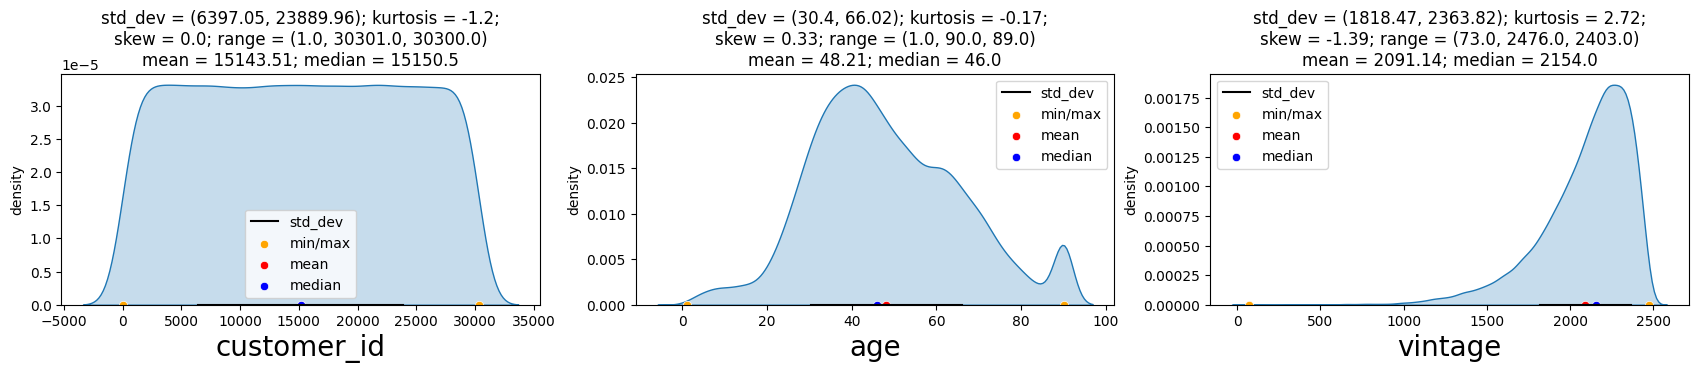

In [23]:
UVA_numeric(data,customer_details)

**Summary of Customer_Information:**
*    **customer_id**:
     *    variable is **unique for every customer, Hence uniform** distribution.
     * This variable **does not contribute any information**
     * Can be eliminated from data

*    **age**:
    *    Median Age = 46
    *    **Most customers are between 28 and 72** (10th to 90th percentile)
    *    skewness +0.33 : customer age is **negligibly biased towards younger age**
    *    **kurtosis = -0.17**; very less likely to have extreme/outlier values.
*    **vintage:**
    *    Most customers joined between about 1,700 and 2,400 days before the data was extracted (10th to 90th percentile).
    *    **skewness** -1.39 : this is left skewed, **vintage variable is significantly biased towards longer association of customers.**
    *    **Kurtosis = 2.72**: Extreme values and Outliers are very likely to be present in vintage.

**Things to Investigate Further down the road:**
*    The batch of **high number of very Old Age customers** in age variable.

### current_month

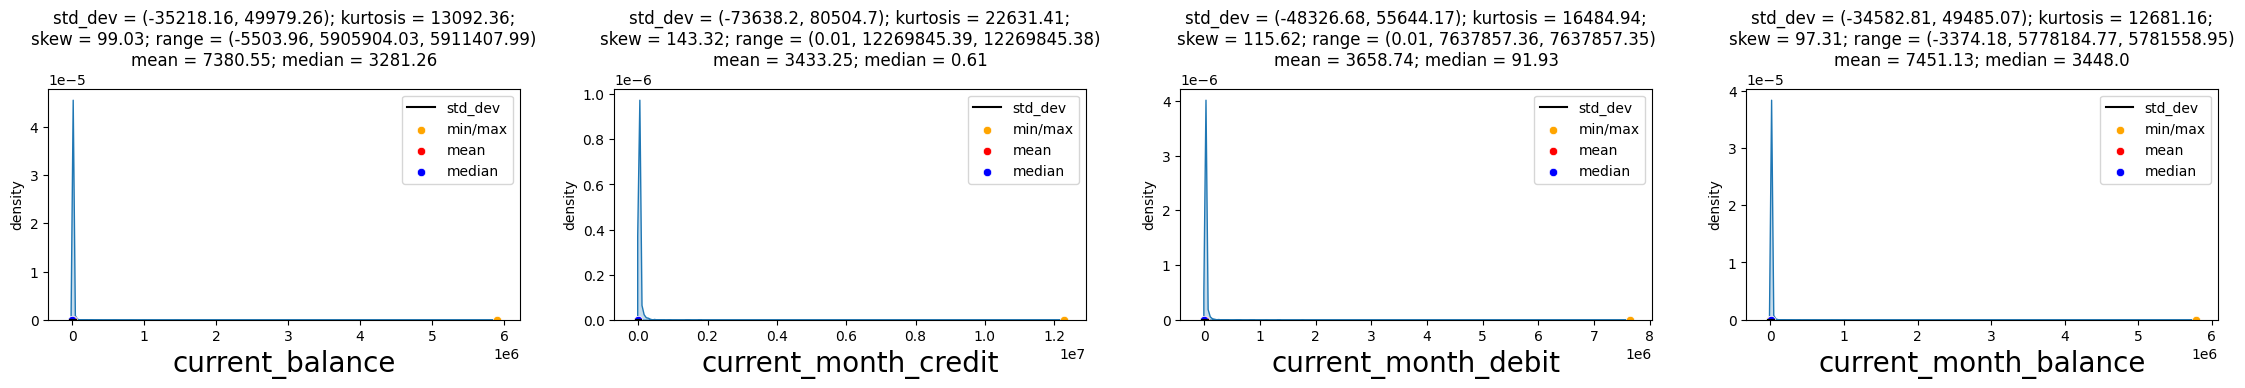

In [24]:
UVA_numeric(data,current_month)

**Summary**
*    Considering the kurtosis and skewness value  for all 4 of these plots. Outliers/Extreme values are obvious.


**Need to Remove Outliers to visulaise these plots**

In [25]:
# standard deviation factor
factor = 3

# copying current_month
cm_data = data[current_month]

# keeping observations within 3 standard deviations of the mean
for col in current_month:
    mean, std = cm_data[col].mean(), cm_data[col].std()
    cm_data = cm_data[(cm_data[col] - mean).abs() <= factor * std]

# checking how many points removed
len(data), len(cm_data)

(28382, 27425)

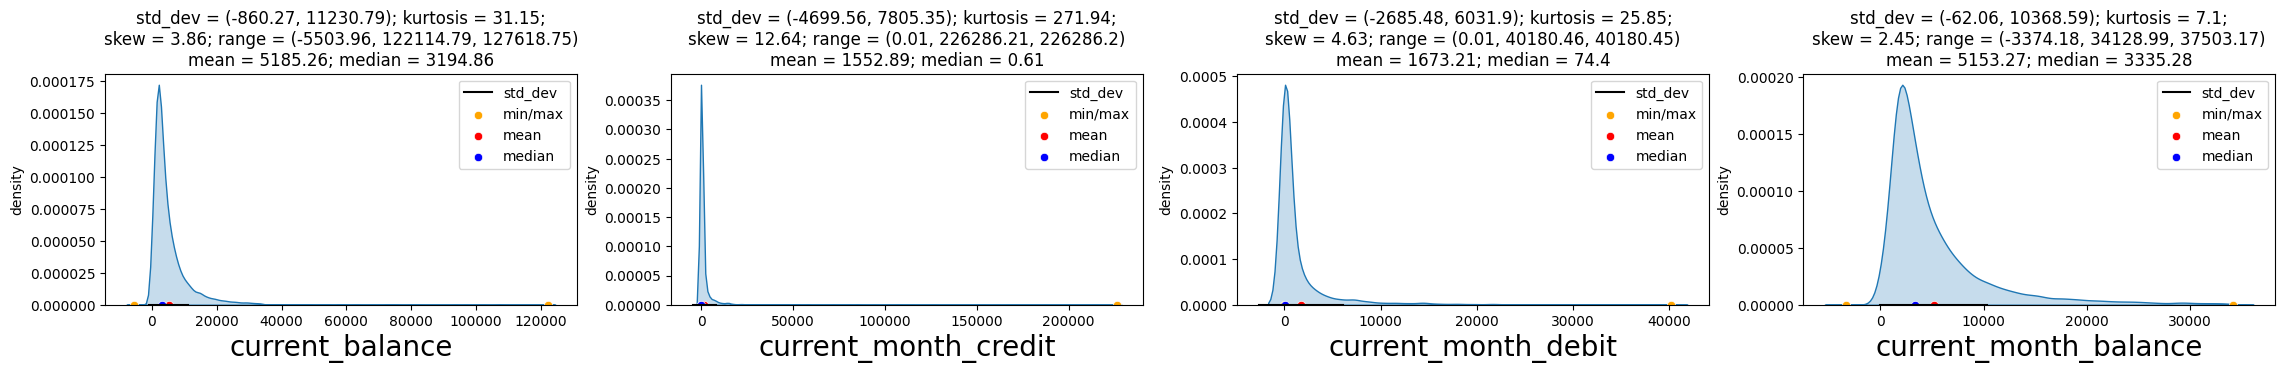

In [26]:
UVA_numeric(cm_data,current_month)

**Summary of current_month**
*    After Removing extreme/outliers, plots are still very skewed.

**Things to investigate further down**
1.    **Is there thete any common trait/relation between the customers who are performing high transaction credit/debits?**
2.    **Customers who are performinng high amount of transactions, are they doinng it every month?**

### previous_month

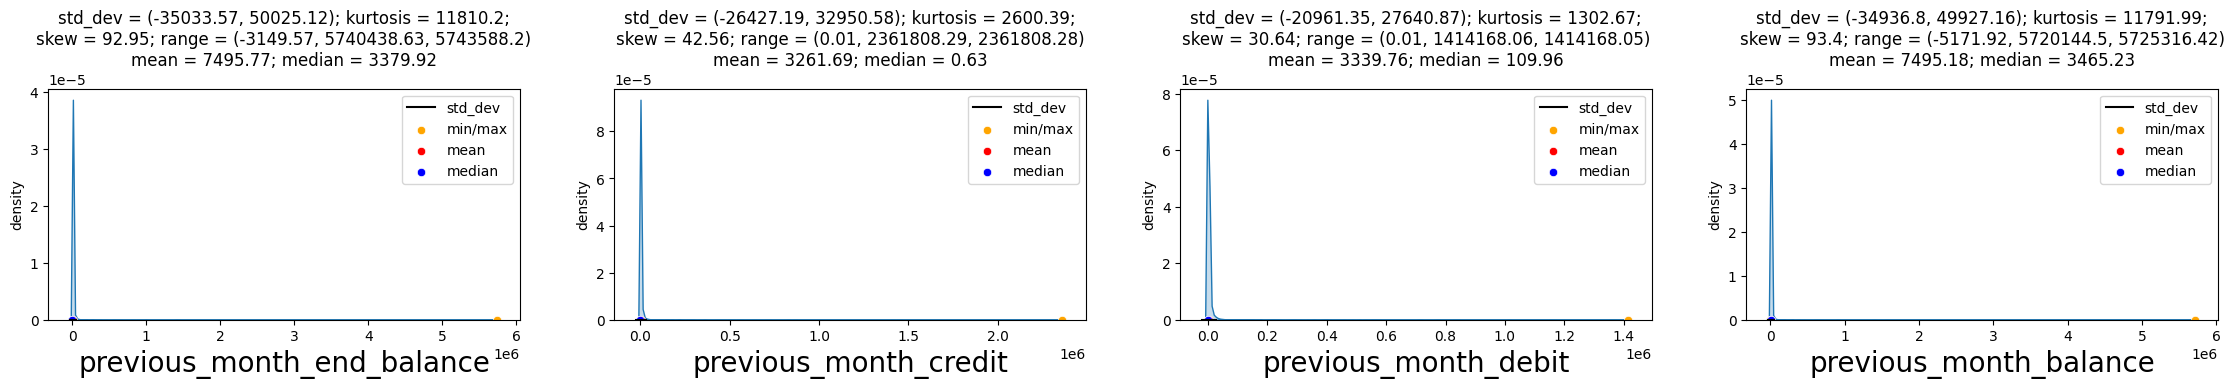

In [27]:
UVA_numeric(data,previous_month)

**Summary of previous_month**
*    This looks very similar to current_month. Most of the customers perform low amount transactions.

### previous_quarters

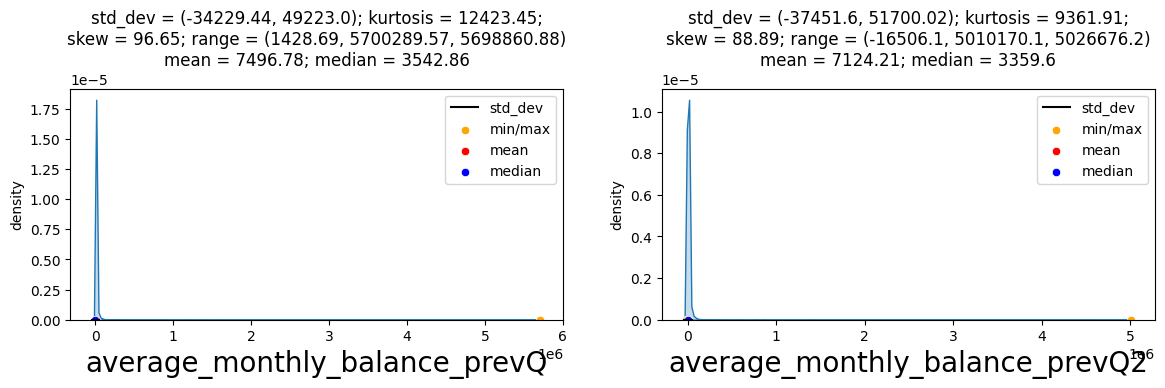

In [28]:
UVA_numeric(data,previous_quarters)

**Summary**
The general trend still follows, it is crutial that we find the out if there is any common trait between the customers doing high high amount of transactions.

### transaction_date

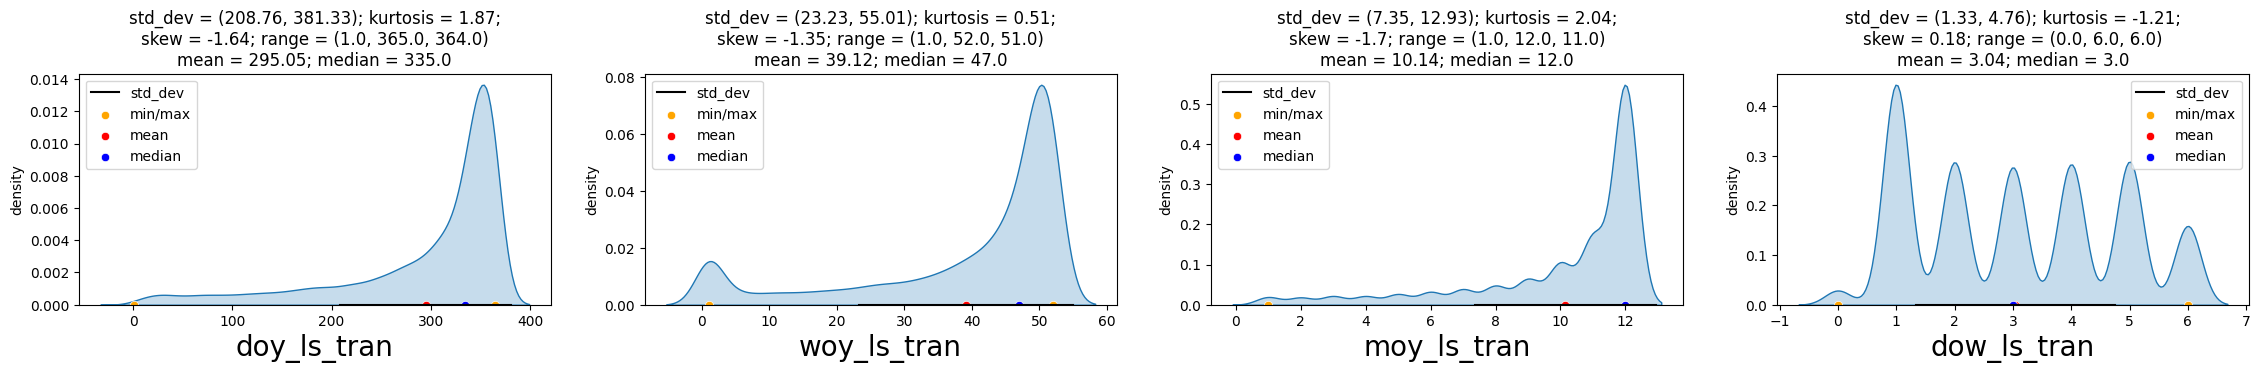

In [29]:
UVA_numeric(data,transaction_date)

**Summary**
*    **Day_of_Year**:
    *    about two thirds of last transactions (65% of customers with a recorded date) fall in the final 60 days before the data was extracted.
    *    There are transactions which were made also an year ago.

*   **Week_of_year and Month_of_year**: these variable validate the findings from the **day_of_year**.
*    **Day_of_Week**: Tuesdays are the most common day for a last transaction, and Mondays very rare.

**Things to investigate further Down**
*    **Customers whose last transaction was 6 months ago, did all of them churn?**

## Univariate Analysis : Categorical Varibales

In [30]:
data.select_dtypes(exclude=['int64','float64','Int64']).dtypes

gender                  category
occupation              category
city                    category
customer_nw_category    category
branch_code             category
churn                   category
dtype: object

**Grouping Varibales**

* **customer_info**: gender, occupation, customer_nw_category
* **account_info**: city, branch_code
* **churn**

In [31]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (7*size,5), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.barplot(x=norm_count.values, y=norm_count.index.astype(str), order=norm_count.index.astype(str))
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))

### customer_info

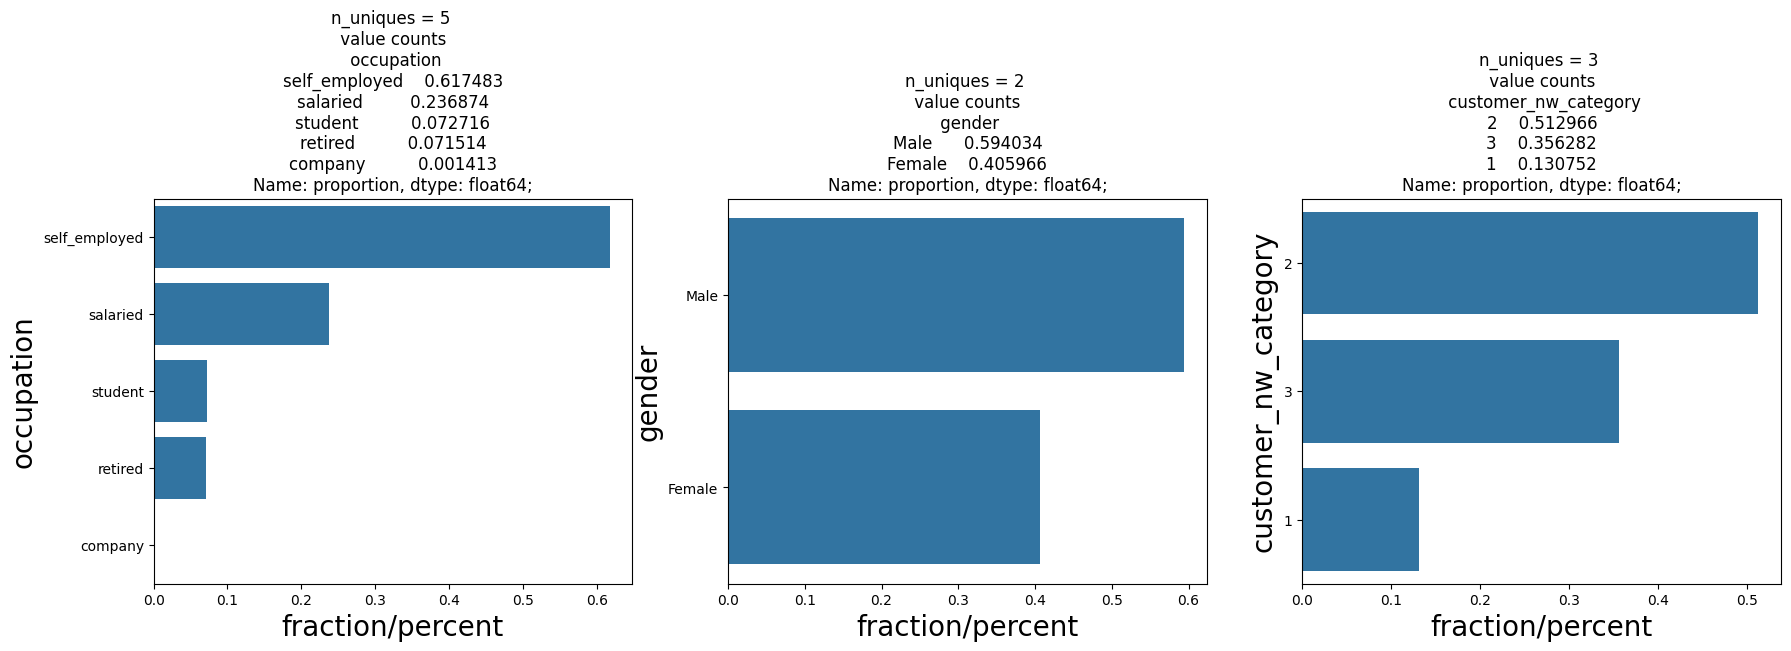

In [32]:
UVA_category(data, ['occupation', 'gender', 'customer_nw_category'])

**Summary**
* Occupation
  * Majority of people are self_employed.
  * There are extremely few Company Accounts. Might explain Outlier/Extreme values in credit/debit.

* Gender:
  *  Males accounts are 1.5 times more than Female Accounts.

* customer_nw_category:
  *  Half of all accounts (51%) belong to net worth category 2, and 36% to category 3.
  *  Only 13% belong to category 1.

**Things to investigate further down:**
* Possibility: Company accounts are the reason behind the outlier transactions.
* Possibility: customers belonging to the highest net worth category may explain the skewness of the transactions.

### account_info

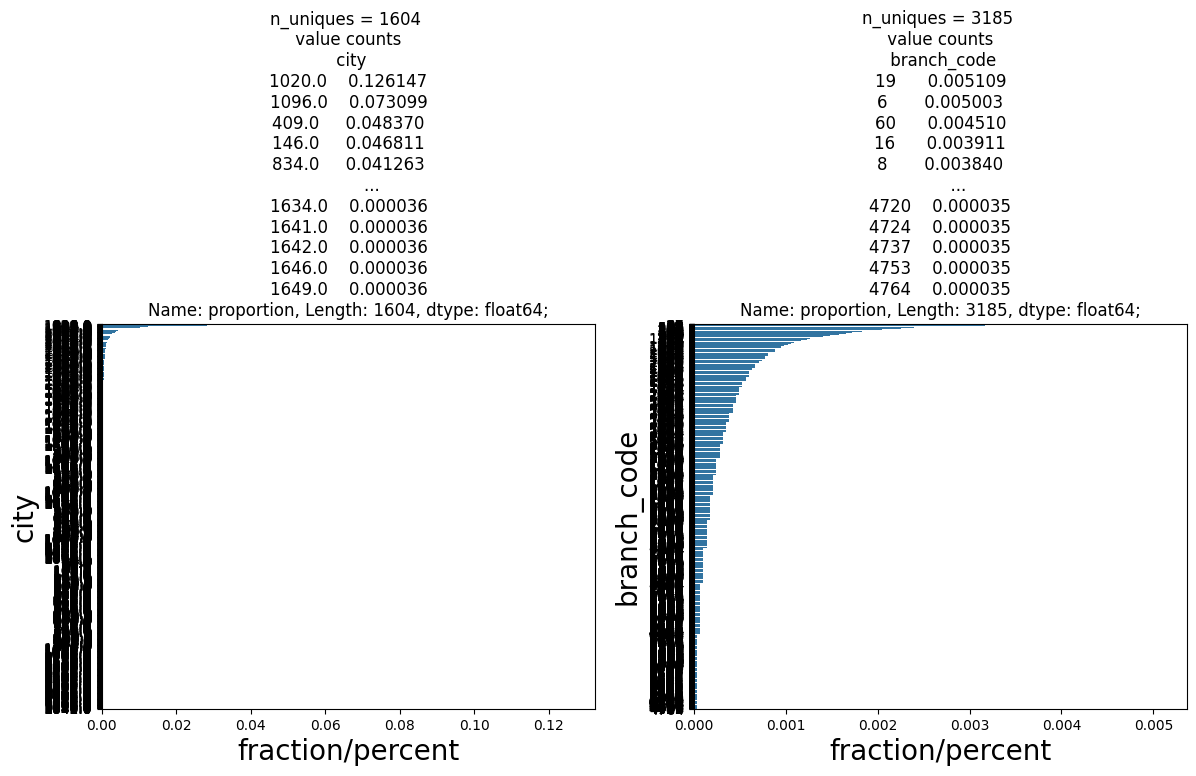

In [33]:
UVA_category(data, ['city', 'branch_code'])

(0.0, 0.02)

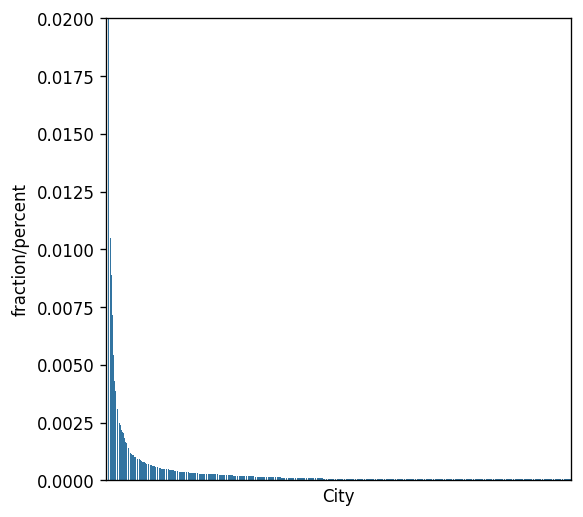

In [34]:
#Plotting "city"
plt.figure(figsize = (5,5), dpi = 120)
city_count = data['city'].value_counts(normalize=True)
sns.barplot(x=city_count.index.astype(str), y=city_count.values, order=city_count.index.astype(str))
plt.xticks([])
plt.xlabel('City')
plt.ylabel('fraction/percent')
plt.ylim(0,0.02)

Text(0, 0.5, 'number of accounts')

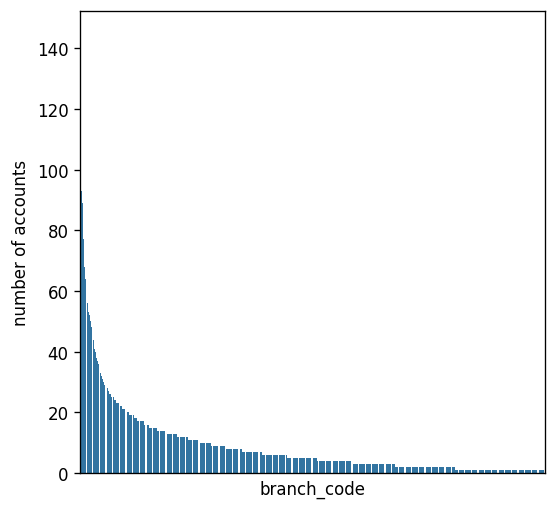

In [35]:
#Plotting "branch_code"
plt.figure(figsize = (5,5), dpi = 120)
branch_count = data['branch_code'].value_counts()
sns.barplot(x=branch_count.index.astype(str), y=branch_count.values, order=branch_count.index.astype(str))
plt.xticks([])
plt.xlabel('branch_code')
plt.ylabel('number of accounts')
#plt.ylim(0,0.02)

**Summary:**
for both variable "city" and "branch_code", there are too many categories. There is clear relation that some branches and cities are more popular with customers and and this trend decreases rapidly.

**Things to investigate further Down**
* Popular cities and branch code might be able to explain the skewness and outliers of credit/debit variables.
* Possibility that cities and branch code with very few accounts may lead to churning.

### churn

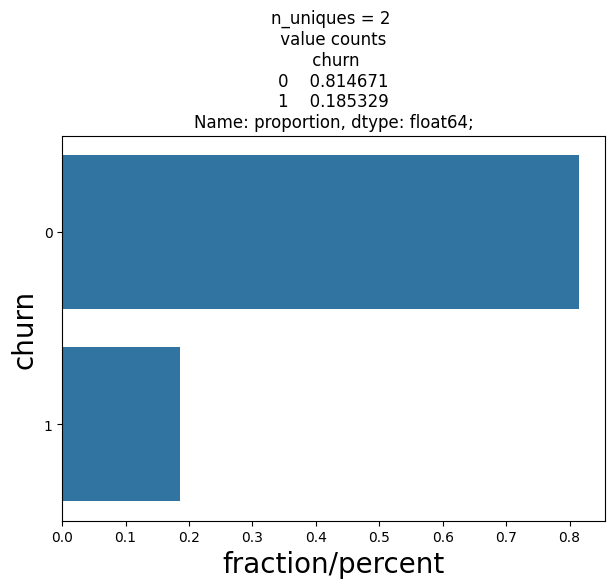

In [36]:
UVA_category(data, ['churn'])

**Summary**
* 18.5% of customers churned: roughly 1 churner for every 4.4 customers who stayed.

## Univariate: Missing Values

In [37]:
# finding number of missing values in every variable
data.isnull().sum()

customer_id                          0
vintage                              0
age                                  0
gender                             525
dependents                        2463
occupation                          80
city                               803
customer_nw_category                 0
branch_code                          0
current_balance                      0
previous_month_end_balance           0
average_monthly_balance_prevQ        0
average_monthly_balance_prevQ2       0
current_month_credit                 0
previous_month_credit                0
current_month_debit                  0
previous_month_debit                 0
current_month_balance                0
previous_month_balance               0
churn                                0
doy_ls_tran                       3223
woy_ls_tran                       3223
moy_ls_tran                       3223
dow_ls_tran                       3223
days_since_tran                   3223
dtype: int64

**Things to investigate further down:**
*    Gender: Do the customers with missing gender values have some common behaviour in-
  * churn: do missing values have any relation with churn?

* Dependents:
 * Missing values might be similar to zero dependents
 * churn: do missing values have any relation with churn?

* Occupation:
 * Do missing values have similar behaviour to any other occupation
 * do they have some relation with churn?

* city:
  * the respective cities can be found using branch_code

* last_transaction:
  * checking their previous month and current month and previous_quarter activity might give insight on their last transaction.

* For almost all the above:

  * vintage: might be recording errors from same period of joining
  * branch_code: might be recording error from certain branch


## Univariate Analysis: Outliers

**We suspected outliers in current_month and previous_month variable groups. We will verify that using bo plots**

In [38]:
# custom function for easy outlier analysis

def UVA_outlier(data, var_group, include_outlier = True):
  '''
  Univariate_Analysis_outlier:
  takes a group of variables (INTEGER and FLOAT) and plot/print boplot and descriptives\n
  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it \n\n

  data : dataframe from which to plot from\n
  var_group : {list} type Group of Continuous variables\n
  include_outlier : {bool} whether to include outliers or not, default = True\n
  '''

  size = len(var_group)
  plt.figure(figsize = (7*size,4), dpi = 100)
  
  #looping for each variable
  for j,i in enumerate(var_group):
    
    # calculating descriptives of variable
    quant25 = data[i].quantile(0.25)
    quant75 = data[i].quantile(0.75)
    IQR = quant75 - quant25
    med = data[i].median()
    whis_low = quant25-(1.5*IQR)
    whis_high = quant75+(1.5*IQR)

    # Calculating Number of Outliers
    outlier_high = len(data[i][data[i]>whis_high])
    outlier_low = len(data[i][data[i]<whis_low])

    if include_outlier == True:
      #Plotting the variable with every information
      plt.subplot(1,size,j+1)
      sns.boxplot(y=data[i])
      plt.ylabel('{}'.format(i))
      plt.title('With Outliers\nIQR = {}; Median = {} \n 2nd,3rd  quartile = {};\n Outlier (low/high) = {} \n'.format(
                                                                                                   float(round(IQR,2)),
                                                                                                   float(round(med,2)),
                                                                                                   (float(round(quant25,2)),float(round(quant75,2))),
                                                                                                   (outlier_low,outlier_high)
                                                                                                   ))
      
    else:
      # replacing outliers with max/min whisker
      data2 = data[var_group].copy()
      data2[i] = data2[i].clip(lower=whis_low, upper=whis_high)
      
      # plotting without outliers
      plt.subplot(1,size,j+1)
      sns.boxplot(y=data2[i])
      plt.ylabel('{}'.format(i))
      plt.title('Without Outliers\nIQR = {}; Median = {} \n 2nd,3rd  quartile = {};\n Outlier (low/high) = {} \n'.format(
                                                                                                   float(round(IQR,2)),
                                                                                                   float(round(med,2)),
                                                                                                   (float(round(quant25,2)),float(round(quant75,2))),
                                                                                                   (outlier_low,outlier_high)
                                                                                                   ))

### current_month and previous_month

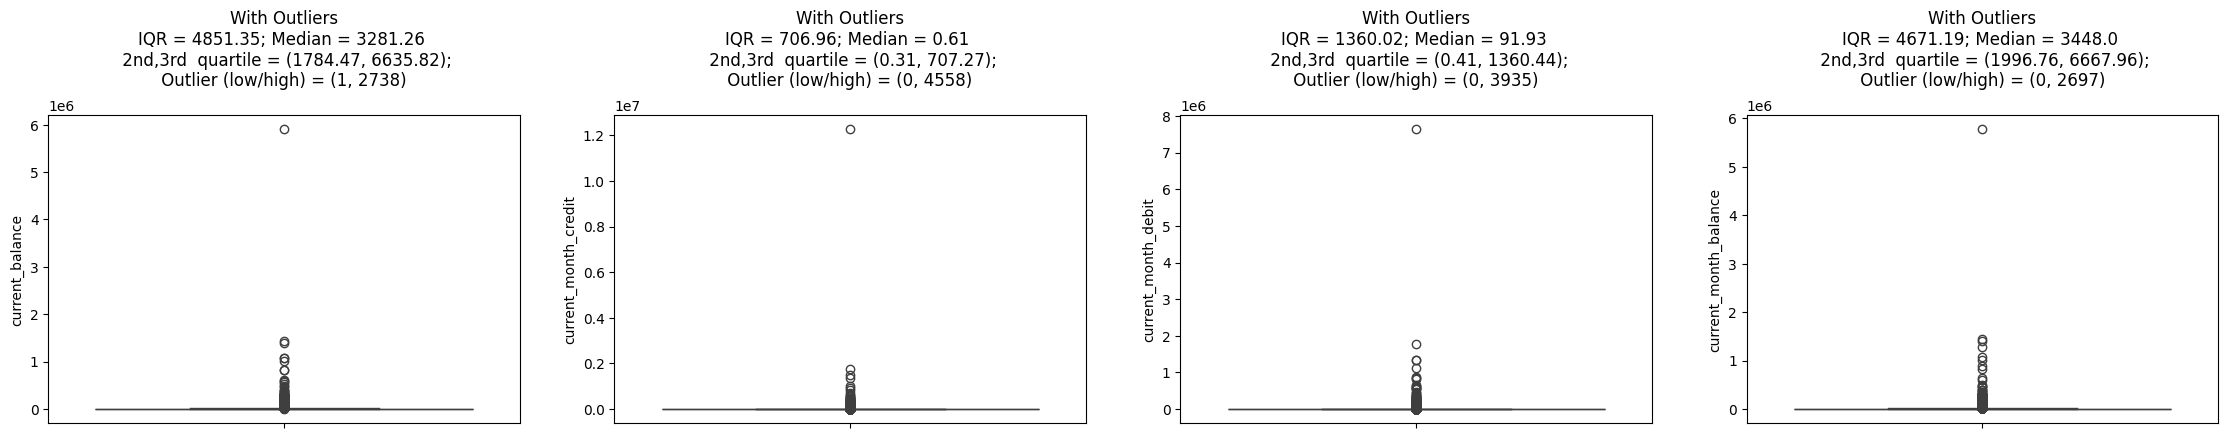

In [39]:
UVA_outlier(data, current_month,)

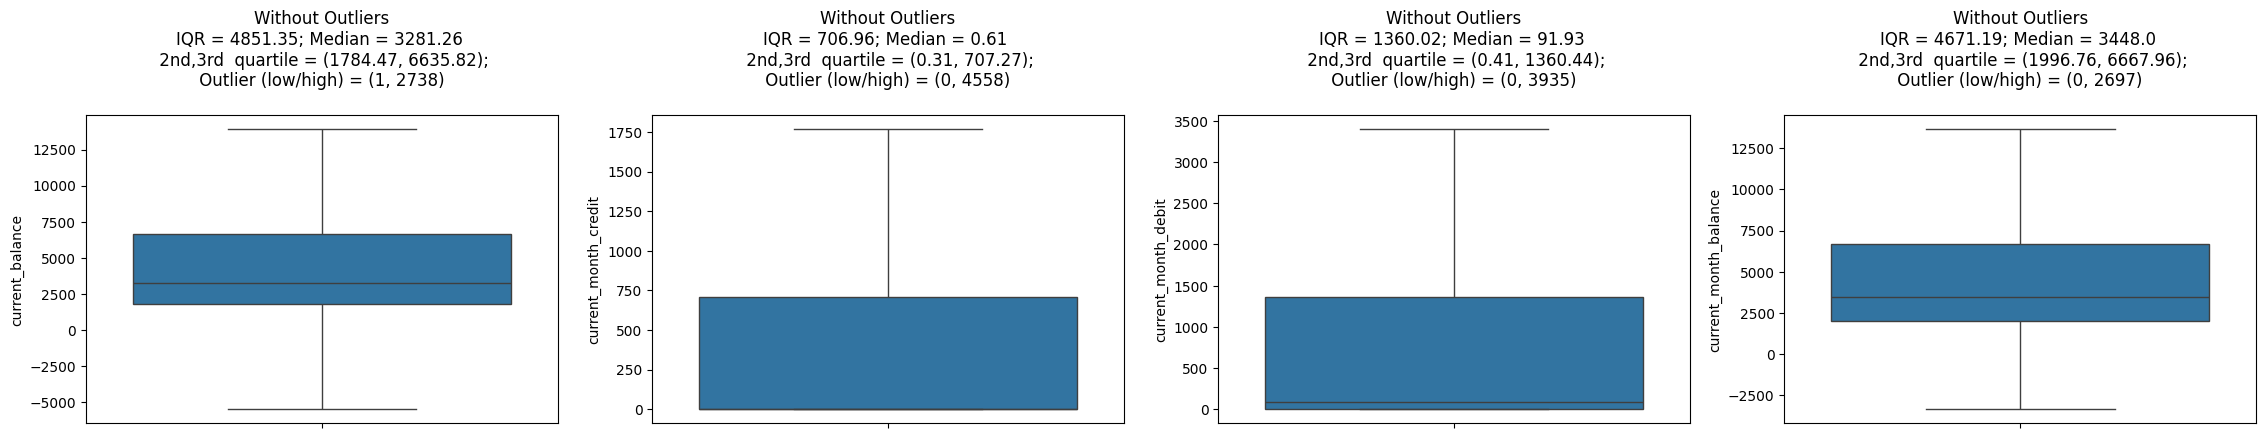

In [40]:
UVA_outlier(data, current_month, include_outlier=False)

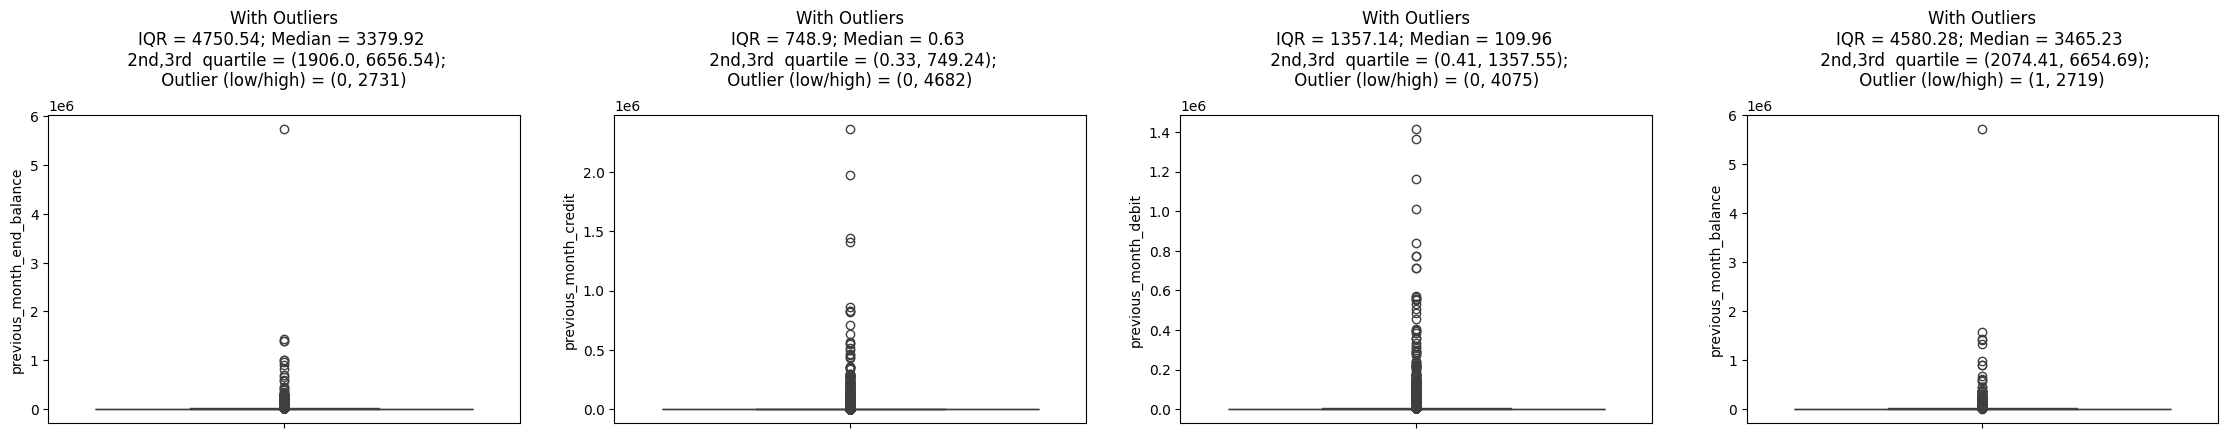

In [41]:
UVA_outlier(data, previous_month)

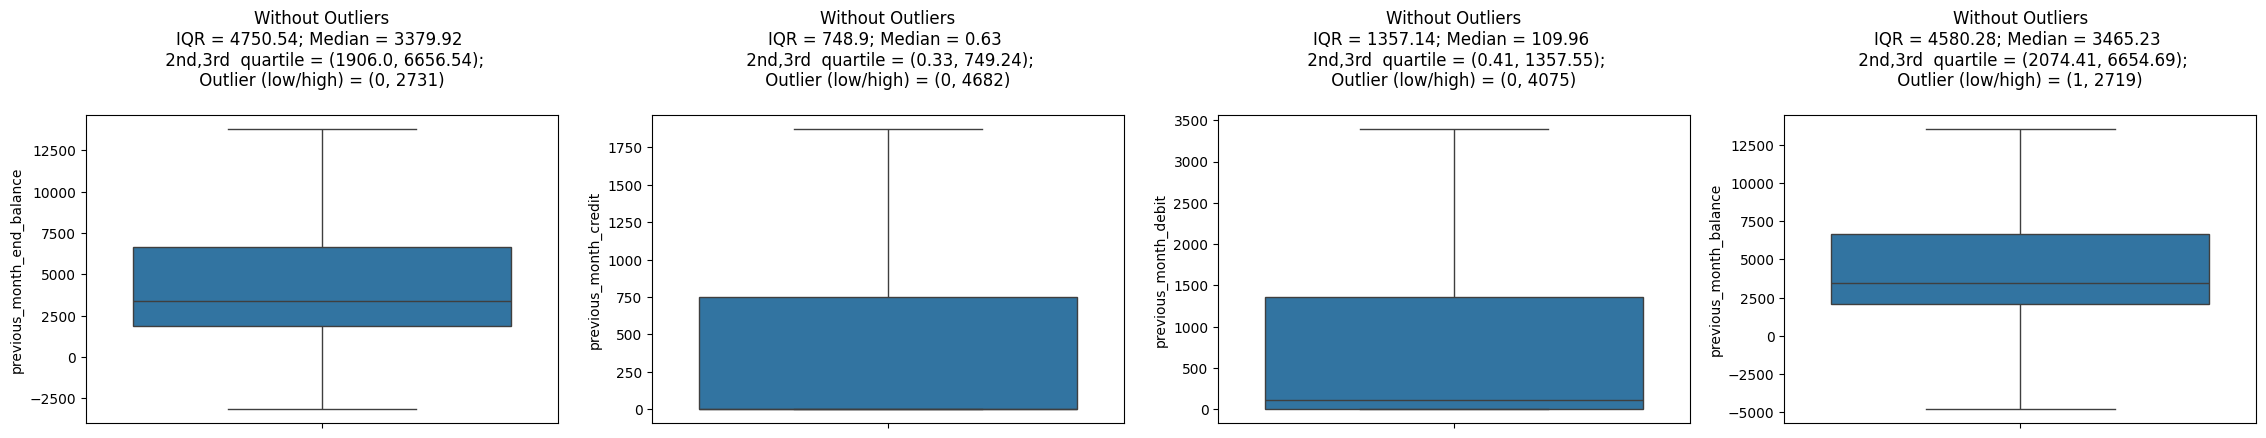

In [42]:
UVA_outlier(data, previous_month, include_outlier=False)

**Summary:**
* If we look at corresponding plots in the outputs above, there seems to be a strong relation between the corresponding plots of previous_month and current_month variables.

* Outliers are significant in number and very similar in number between corresponding plots. Which indicates some inherent undiscovered behviour of Outliers.

### previous quarters

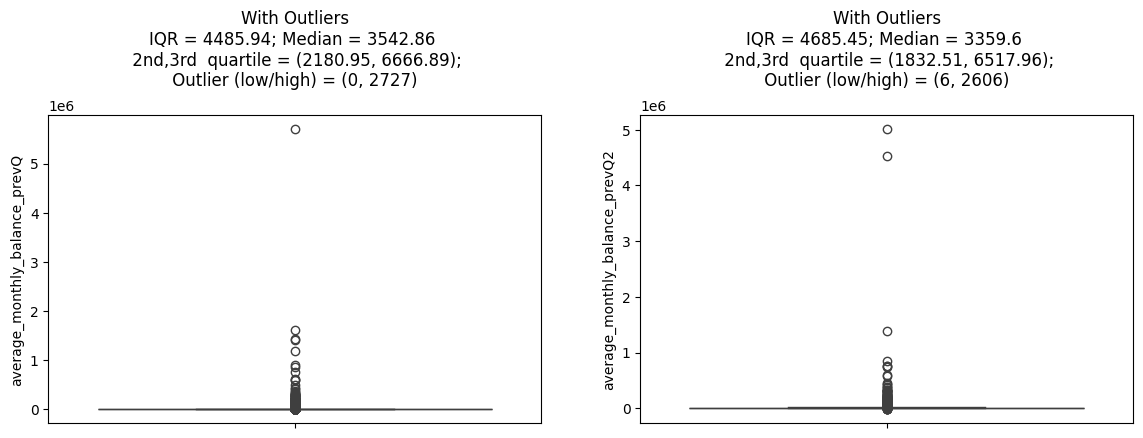

In [43]:
UVA_outlier(data,previous_quarters)

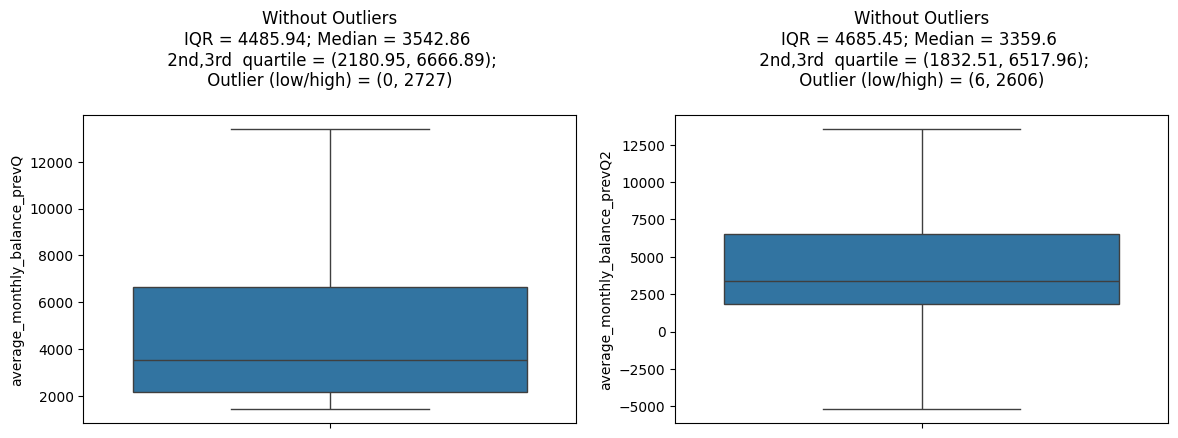

In [44]:
UVA_outlier(data,previous_quarters, include_outlier = False)

Summary:
* Outliers in previous two quarters are very similar but significantly large in number.

## Investigation directions from Univariate Analysis
1. customer_id variable can be dropped.
2.  Is there there any common trait/relation between the customers who are performing high transaction credit/debits?
   * customer_nw_category might explain that.
   * Occupation = Company might explain them
   * popular cities might explain this
4.  Customers whose last transaction was 6 months ago, did all of them churn? 
5. Possibility that cities and branch code with very few accounts may lead to churning.


## Bivariate Analysis : Numerical-Numerical

In [45]:
# isolating numerical datatypes
numerical = data.select_dtypes(include=['int64','float64','Int64'])[:]
numerical.dtypes

customer_id                         int64
vintage                             int64
age                                 int64
dependents                          Int64
current_balance                   float64
previous_month_end_balance        float64
average_monthly_balance_prevQ     float64
average_monthly_balance_prevQ2    float64
current_month_credit              float64
previous_month_credit             float64
current_month_debit               float64
previous_month_debit              float64
current_month_balance             float64
previous_month_balance            float64
doy_ls_tran                       float64
woy_ls_tran                         Int64
moy_ls_tran                       float64
dow_ls_tran                       float64
days_since_tran                   float64
dtype: object

### Correlation Matrix

In [46]:
# calculating correlation
correlation = numerical.dropna().corr()
correlation

,customer_id,vintage,age,dependents,current_balance,previous_month_end_balance,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,doy_ls_tran,woy_ls_tran,moy_ls_tran,dow_ls_tran,days_since_tran
customer_id,1.000000,-0.011288,0.001397,-0.009737,0.014989,0.012414,0.011372,0.008060,0.004223,-0.004819,0.004870,-0.005906,0.012085,0.011025,-0.006114,0.011344,-0.005374,0.009665,0.005543
vintage,-0.011288,1.000000,0.003170,0.005109,-0.007223,-0.008001,-0.010858,-0.003824,-0.004821,-0.000410,-0.004899,-0.007777,-0.008703,-0.010439,-0.000680,-0.010040,-0.001359,-0.009683,0.000689
age,0.001397,0.003170,1.000000,-0.003809,0.058925,0.062775,0.070903,0.081361,0.023921,0.027678,0.025366,0.027717,0.063120,0.067712,0.010754,0.000501,0.011970,-0.020895,-0.011035
dependents,-0.009737,0.005109,-0.003809,1.000000,-0.004554,-0.000826,0.000121,0.002584,0.002188,0.022772,0.006784,0.029073,-0.001859,0.000241,0.079740,0.034460,0.077978,-0.001702,-0.079834
current_balance,0.014989,-0.007223,0.058925,-0.004554,1.000000,0.809257,0.857204,0.584156,0.053329,0.101495,0.075149,0.151771,0.940234,0.812295,0.035242,-0.008980,0.033127,-0.000315,-0.035241
previous_month_end_balance,0.012414,-0.008001,0.062775,-0.000826,0.809257,1.000000,0.908053,0.661439,0.051080,0.195149,0.100379,0.192376,0.910206,0.912269,0.024130,0.000946,0.023485,0.002033,-0.024140
average_monthly_balance_prevQ,0.011372,-0.010858,0.070903,0.000121,0.857204,0.908053,1.000000,0.731953,0.051294,0.138967,0.091491,0.187226,0.920943,0.983797,0.021103,-0.000577,0.020949,0.000647,-0.021114
average_monthly_balance_prevQ2,0.008060,-0.003824,0.081361,0.002584,0.584156,0.661439,0.731953,1.000000,0.085542,0.127557,0.098455,0.162203,0.642531,0.701780,0.010306,-0.012720,0.009123,-0.002463,-0.010328
current_month_credit,0.004223,-0.004821,0.023921,0.002188,0.053329,0.051080,0.051294,0.085542,1.000000,0.165102,0.941455,0.116125,0.055339,0.055020,0.031828,0.008664,0.030267,0.000752,-0.031829
previous_month_credit,-0.004819,-0.000410,0.027678,0.022772,0.101495,0.195149,0.138967,0.127557,0.165102,1.000000,0.160198,0.749628,0.141613,0.178147,0.070141,0.016762,0.066691,-0.006657,-0.070149


### Heatmap

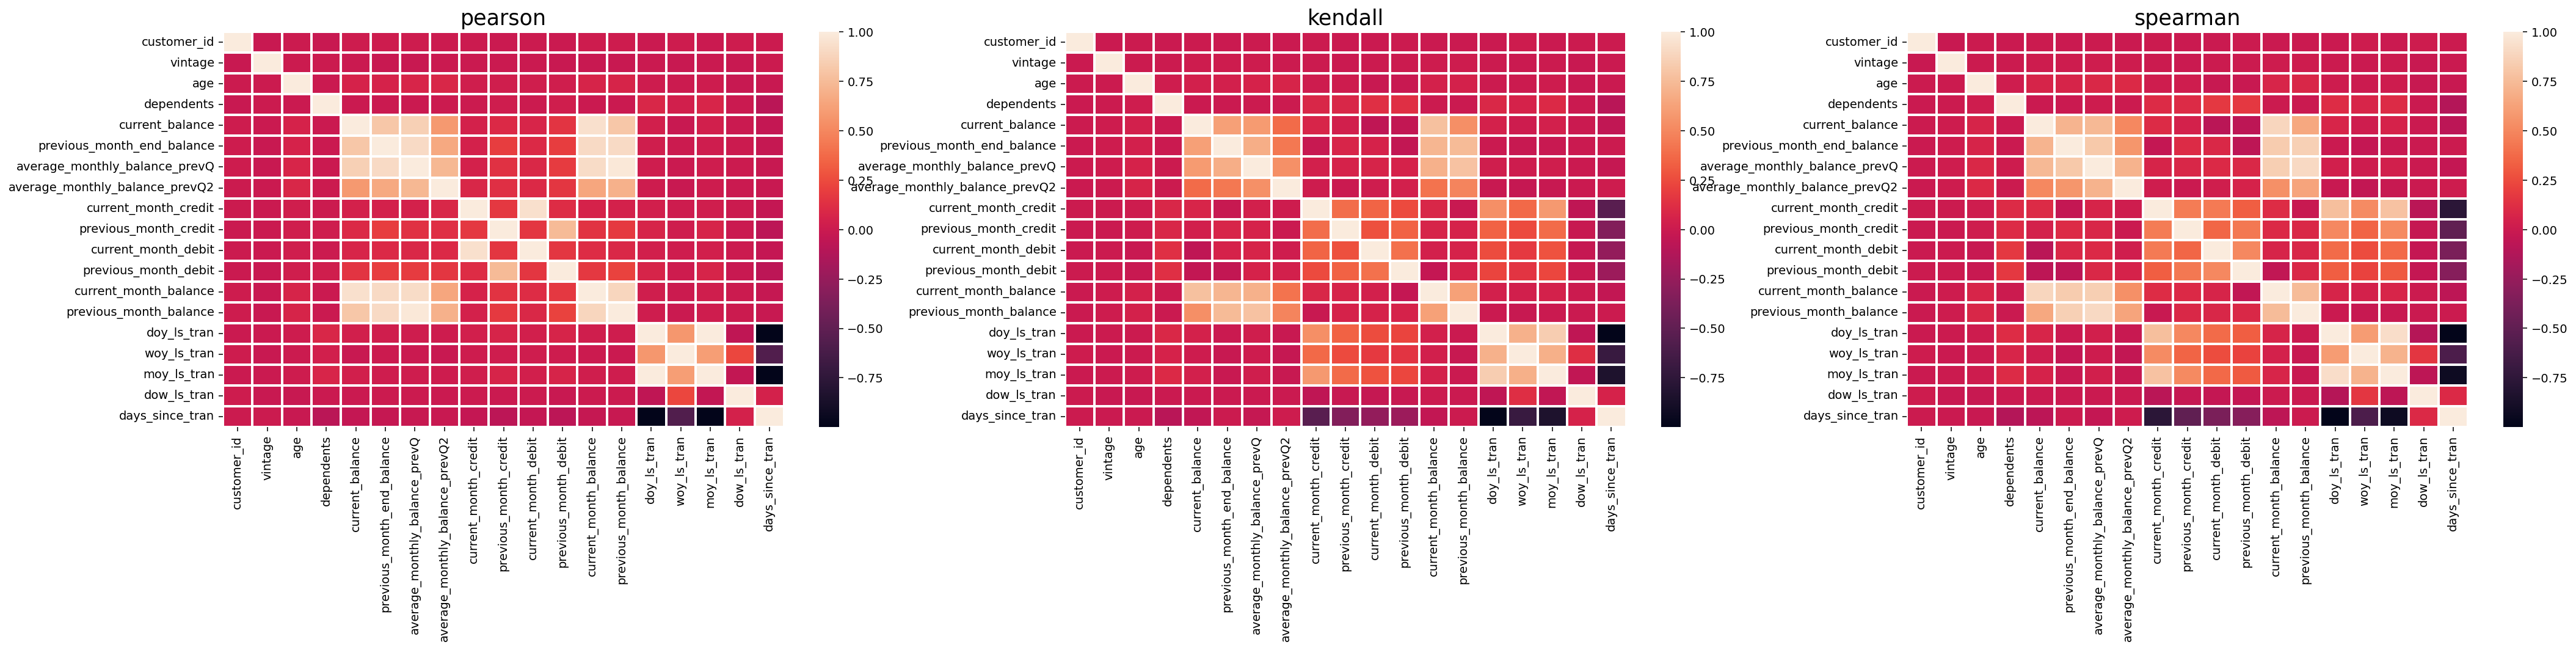

In [47]:
# plotting heatmap usill all methods for all numerical variables
plt.figure(figsize=(36,6), dpi=140)
for j,i in enumerate(['pearson','kendall','spearman']):
  plt.subplot(1,3,j+1)
  correlation = numerical.dropna().corr(method=i)
  sns.heatmap(correlation, linewidth = 2)
  plt.title(i, fontsize=18)



* Kendall and Spearman correlation seem to have very similar pattern between them, except the slight variation in magnitude of correlation.
*  Too many variables with insignificant correlation.
*  Major correlation lies between the transaction variables and balance variables.

In [48]:
# extracting transaction information of current and previous months
var = []
var.extend(previous_month)
var.extend(current_month)
var.extend(previous_quarters)

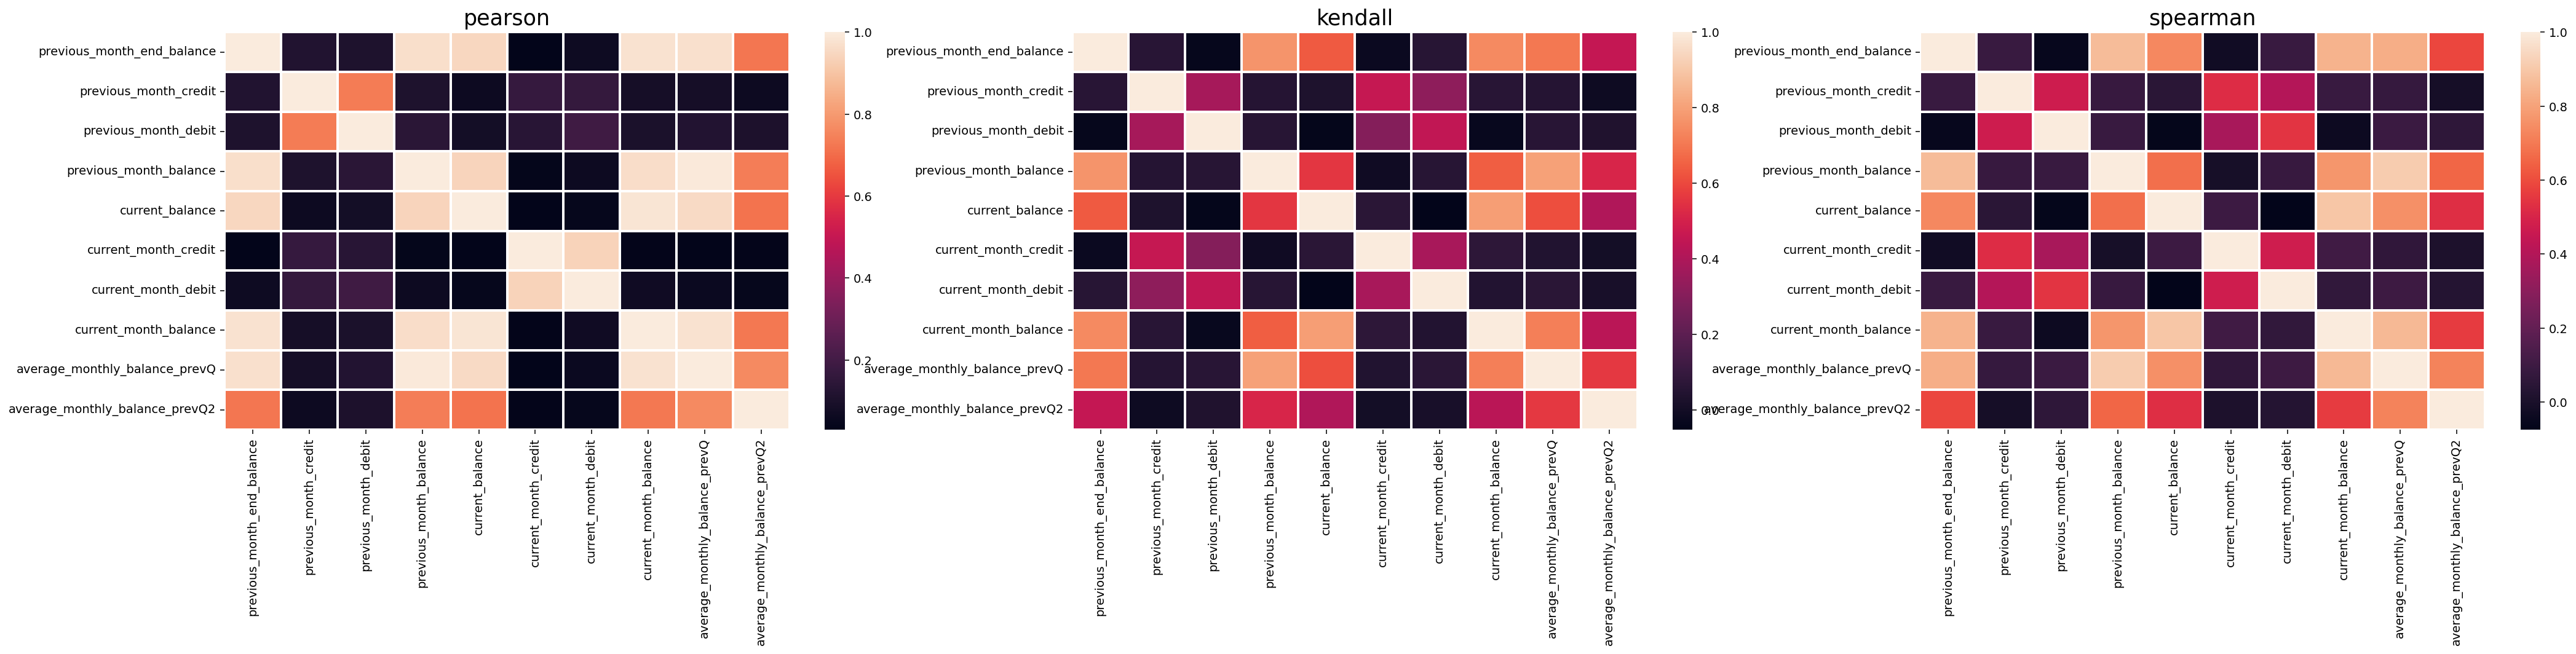

In [49]:
# plotting heatmap usill all methods for all transaction variables
plt.figure(figsize=(36,6), dpi=140)
for j,i in enumerate(['pearson','kendall','spearman']):
  plt.subplot(1,3,j+1)
  correlation = numerical[var].dropna().corr(method=i)
  sns.heatmap(correlation, linewidth = 2)
  plt.title(i, fontsize=18)

**Inferences:**


1.   Transaction variables like credit/debit are moderately correlated among themselves (Spearman 0.4–0.5).
2.  Balance variables have strong correlation among themselves.
3.   Transaction variables like credit/debit have almost no correlation with the balance variables (Spearman below 0.12).



### Scatterplot

In [50]:
# Grouping variables
transactions = ['current_month_credit','current_month_debit','previous_month_credit','previous_month_debit']
balance = ['previous_month_end_balance','previous_month_balance','current_balance','current_month_balance']

<Figure size 896x672 with 0 Axes>

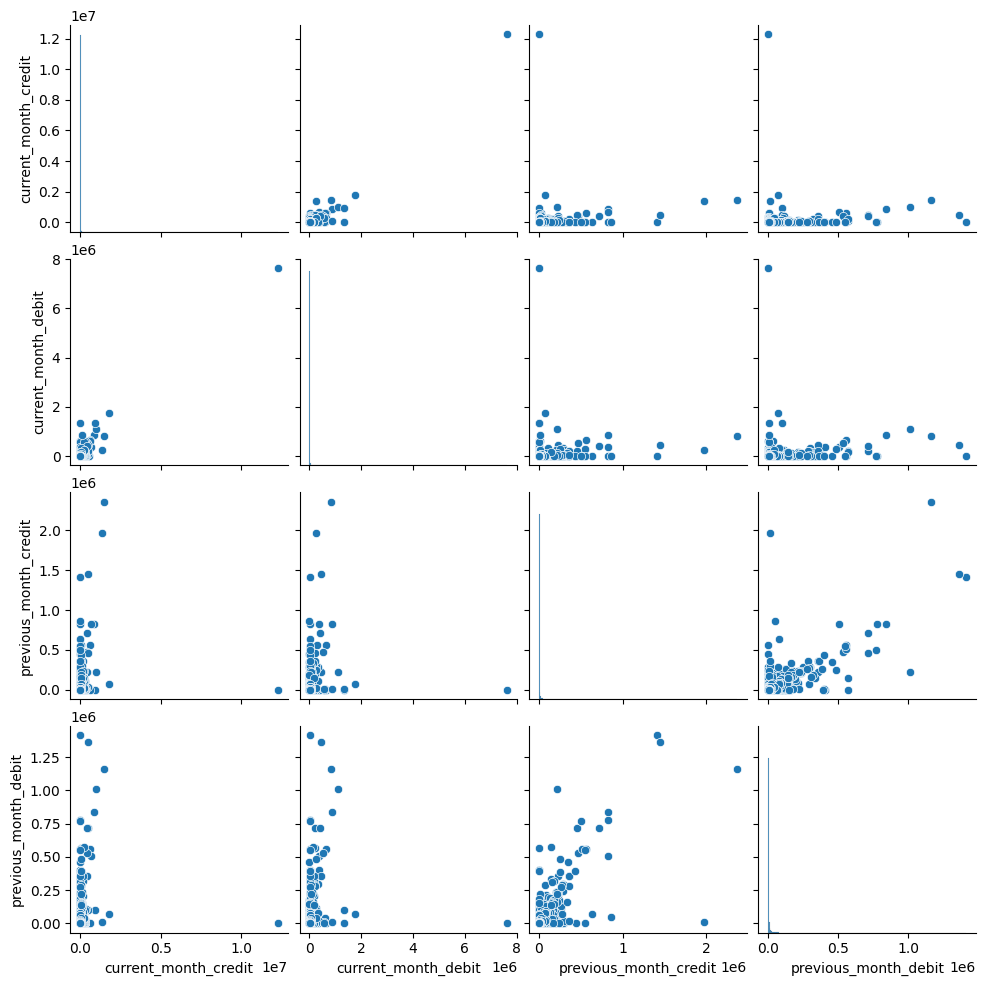

In [51]:
# scatter plot for transactional variables
plt.figure(dpi=140)
sns.pairplot(numerical[transactions])

**the scatter plot is is not meaningful due to the presence of outliers**

In [52]:
#taking log of every value to negate outliers
for column in var:
  mini=1
  if numerical[column].min()<0:
    mini =  abs(numerical[column].min()) + 1
  
  numerical[column] = [i+mini for i in numerical[column]]
  numerical[column] = numerical[column].map(lambda x : np.log(x))

<Figure size 896x672 with 0 Axes>

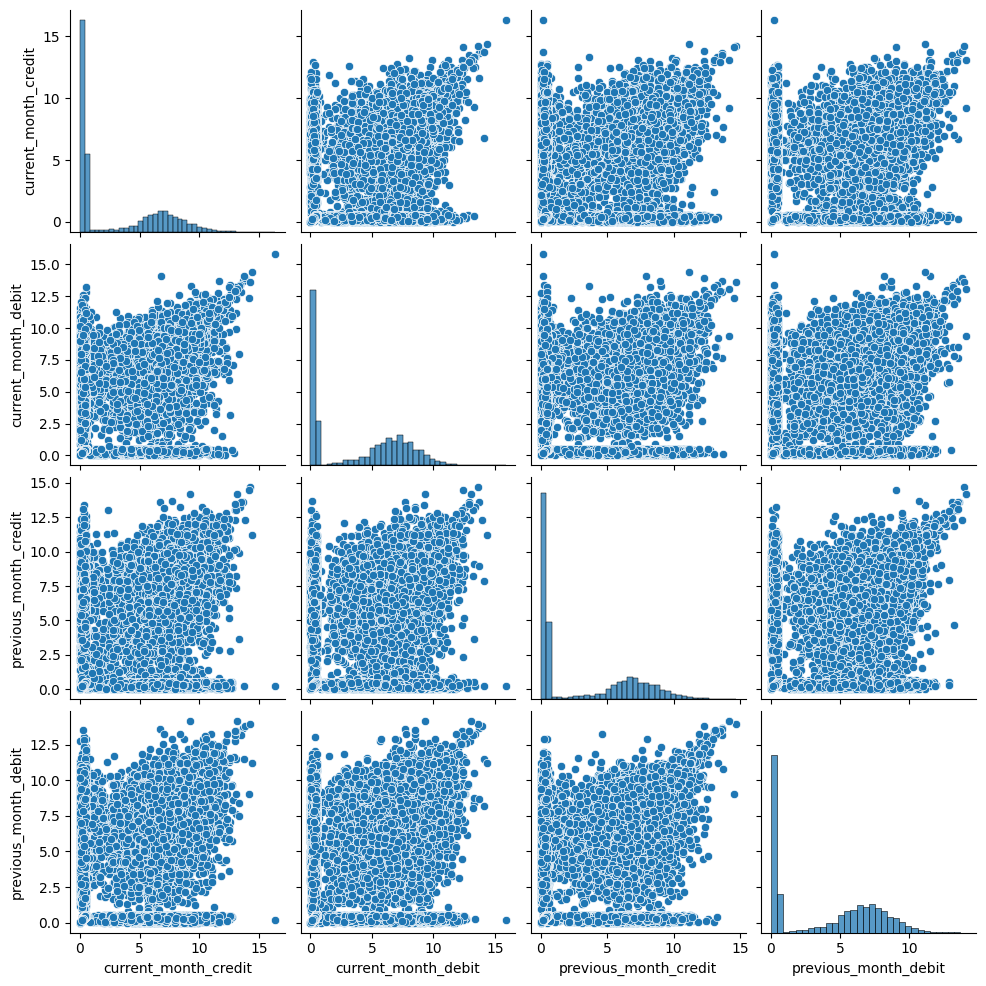

In [53]:
# scatter plot for transactional variables
plt.figure(dpi=140)
sns.pairplot(numerical[transactions])

**Inferences**
1.    On a log scale, the transaction variables show the moderate positive relationship seen in the correlation matrix.
2.    This high correlation can be used for feature engineering during the later stages.

<Figure size 896x672 with 0 Axes>

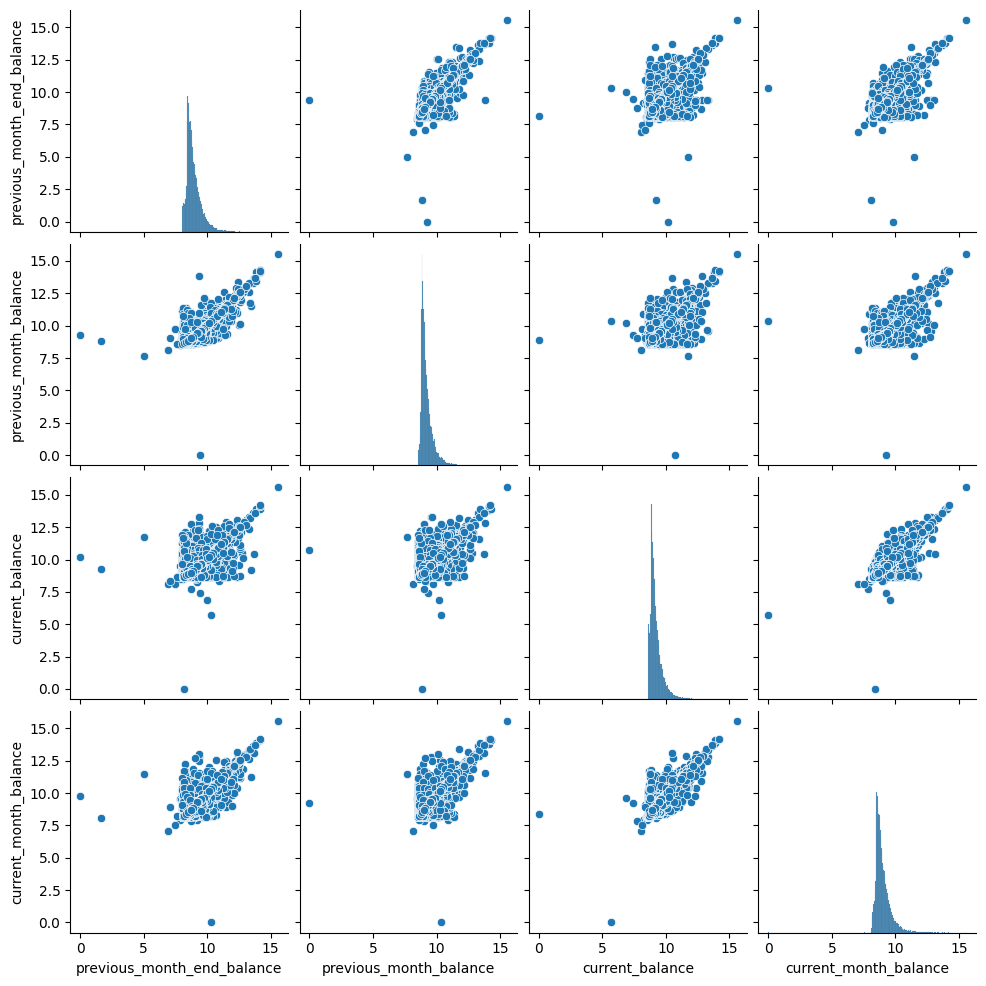

In [54]:
# balance variables
plt.figure(dpi=140)
sns.pairplot(numerical[balance])

**Inferences**
1.    This validates the high correlation between the balance variables.
2.    This high correlation can be used for feature engineering during the later stages.

<Axes: xlabel='average_monthly_balance_prevQ', ylabel='average_monthly_balance_prevQ2'>

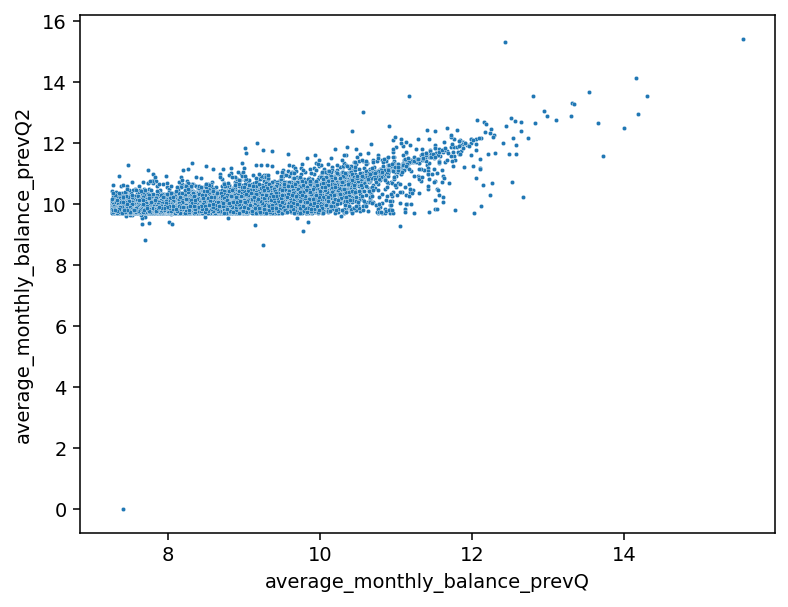

In [55]:
# previous quarters
plt.figure(dpi=140)
sns.scatterplot(x=numerical['average_monthly_balance_prevQ'], y=numerical['average_monthly_balance_prevQ2'], s=5)

**Inferences**
1.    This validates the high correlation between the two previous quarters
2.    This high correlation can be used for feature engineering during the later stages.

## Bivariate : Categorical-Categorical

#### List of Hypothesis to check under this combination
1.   Are females less likely to churn than males?
2.   Are young customers more likely to churn?
3.   Are customers in the lower income bracket more likely to churn?
4.   Are customers with dependent(s) less likely to churn?
5.   Customers with an average family size less than 4 are more likely to churn?
6.   Customers whose last transaction was more than 6 months ago, do they have higher churn rate?
7.   Possibility that cities and branch code with very few accounts may lead to churning.

**Missing Values** - finding behaviour

**Gender**: 
  *  Do missing values churn more?

**Dependents**:
  *  Do missing values have any relation with churn?

**Occupation:**
   * Do they have some relation with churn?

In [56]:
def BVA_categorical_plot(data, tar, cat):
  '''
  take data and two categorical variables,
  calculates the chi2 significance and the strength of the association (Cramer's V),
  and prints the churn rate per group with a countplot & stacked bar
  '''
  from scipy.stats import chi2_contingency

  #isolating the variables
  data = data[[cat,tar]].dropna()

  #forming a crosstab and performing chi2 test
  table = pd.crosstab(data[tar], data[cat])
  chi, p, dof, expected = chi2_contingency(table.values)
  cramers_v = np.sqrt(chi / (table.values.sum() * (min(table.shape) - 1)))
  sig = p < 0.05

  # churn rate in each group: the size of the difference, not just its significance
  rates = data.assign(**{tar: data[tar].astype(int)}).groupby(cat, observed=True)[tar].agg(['mean', 'size'])
  rates.columns = ['churn rate', 'customers']
  print(rates.round(3).to_string())
  print(f"\np-value = {p:.2g}; significant = {sig}; Cramer's V = {cramers_v:.3f}")

  #plotting grouped plot
  plt.figure(figsize=(12, 4), dpi=100)
  plt.subplot(1, 2, 1)
  sns.countplot(x=cat, hue=tar, data=data)
  plt.title(f"p-value = {p:.2g}; Cramer's V = {cramers_v:.3f}")

  #plotting percent stacked bar plot
  ax = plt.subplot(1, 2, 2)
  data.groupby(cat, observed=True)[tar].value_counts(normalize=True).unstack().plot(kind='bar', stacked=True, ax=ax)
  plt.title('share churned within each group')
  plt.show()

### 1. Are females less likely to churn than males?

        churn rate  customers
gender                       
Female       0.176      11309
Male         0.192      16548

p-value = 0.00079; significant = True; Cramer's V = 0.020


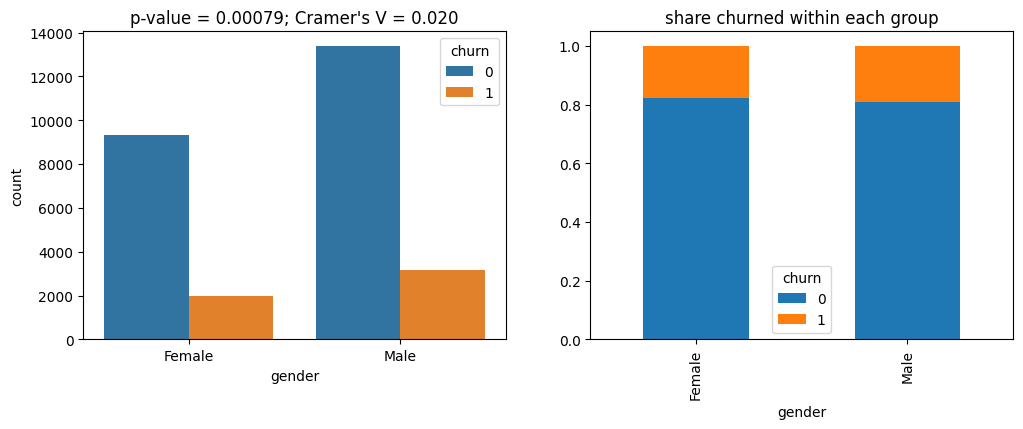

In [57]:
BVA_categorical_plot(data, 'churn', 'gender')

**Result:**

Males churn slightly more than females: 19.2% against 17.6%. The difference is statistically significant (p < 0.001), but it is small: Cramér's V is 0.02, where 0 means no association and 1 a perfect one.

### 2. Are young customers more likely to churn?

In [58]:
# segregating customers into segments
churn = data[['churn','age']].copy()
churn['age_group'] = pd.cut(churn['age'], bins=[-1, 17, 59, 79, 200],
                            labels=['young', 'adult', 'senior citizen', 'very old'])

                churn rate  customers
age_group                            
young                0.129        806
adult                0.194      20107
senior citizen       0.169       5880
very old             0.164       1589

p-value = 5.6e-09; significant = True; Cramer's V = 0.038


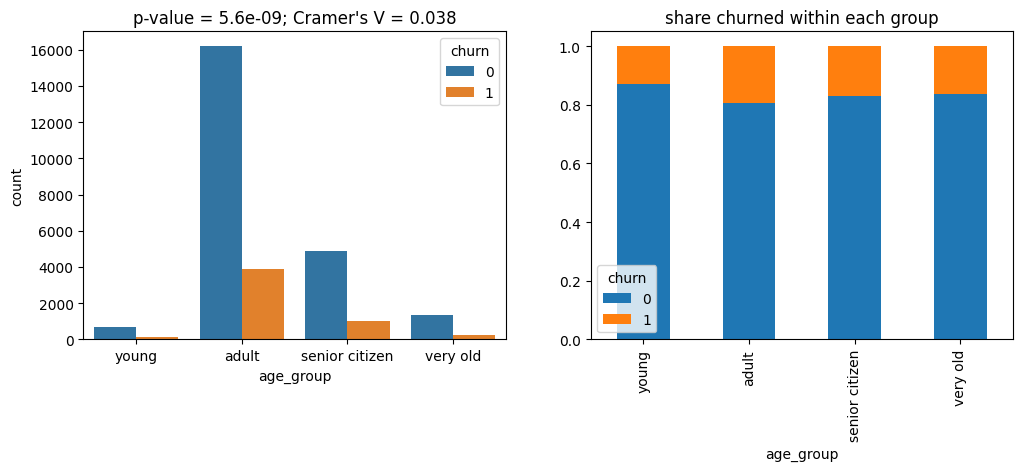

In [59]:
BVA_categorical_plot(churn, 'churn', 'age_group')

**Result:**

Adults (18–59) churn the most at 19.4%, and customers under 18 the least at 12.9%. So the hypothesis is reversed: young customers are *less* likely to churn. The association is weak (Cramér's V 0.04).

### 3. Customers from low income bracket more likely to churn

                      churn rate  customers
customer_nw_category                       
1                          0.191       3711
2                          0.179      14559
3                          0.192      10112

p-value = 0.019; significant = True; Cramer's V = 0.017


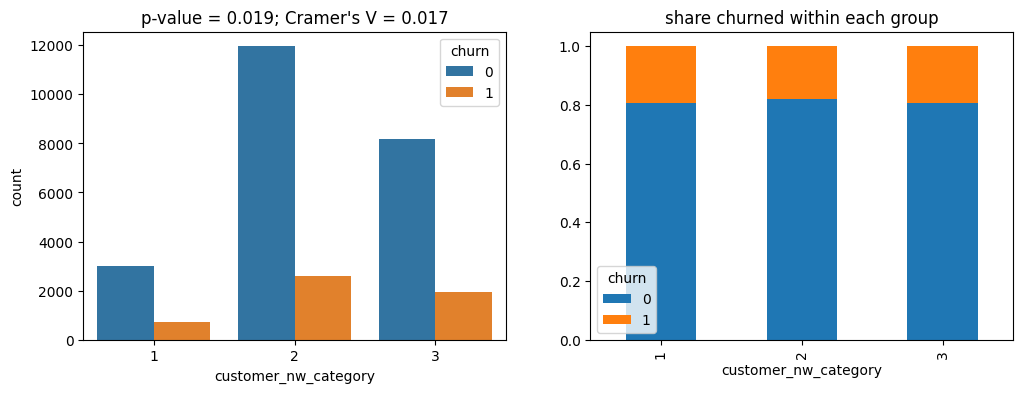

In [60]:
BVA_categorical_plot(data, 'churn', 'customer_nw_category')

**Result:**

Churn is almost the same across net worth categories: 19.1%, 17.9% and 19.2%. The p-value (0.02) is below 0.05 only because the sample is large; the effect is negligible (Cramér's V 0.02), so net worth category does not meaningfully explain churn.

### 4,5. Are customers with dependent(s) less likely to churn?

In [61]:
# segregating dependents into categories
dependents = data[['churn','dependents']].dropna().copy()
dependents['dep_group'] = pd.cut(dependents['dependents'].astype(int), bins=[-1, 0, 3, 9, 1000],
                                 labels=['single', 'small family', 'large family', 'joint family'])

              churn rate  customers
dep_group                          
single             0.174      21435
small family       0.225       4246
large family       0.185        233
joint family       0.200          5

p-value = 4.8e-13; significant = True; Cramer's V = 0.048


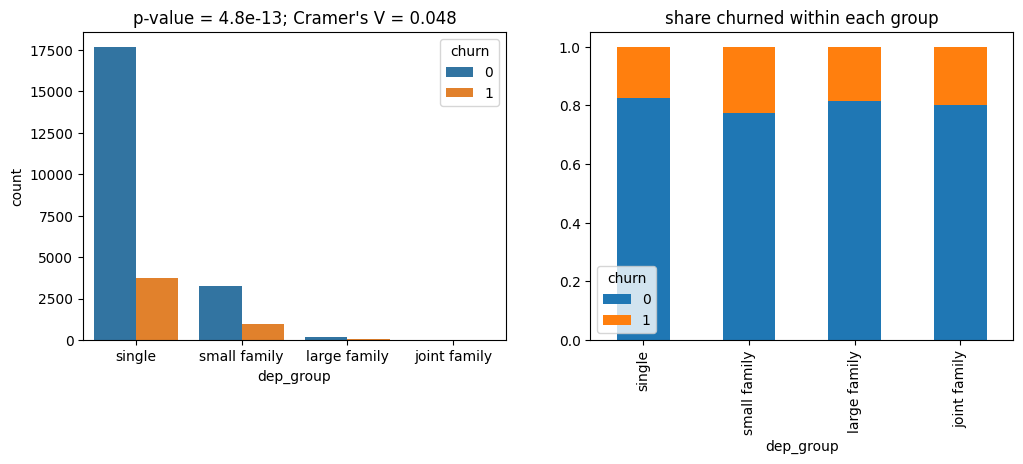

In [62]:
BVA_categorical_plot(dependents, 'churn', 'dep_group')

**Result:**

Customers with 1–3 dependents churn more (22.5%) than customers with none (17.4%). The hypothesis that dependents make customers stay is not supported. The large and joint family groups are too small (233 and 5 customers) to say anything about.

### 6. Customers whose last transaction was more than 6 months ago, do they have a higher churn rate?

Recency is measured as the number of days between each customer's last transaction and the end of the data (31 December 2019), not the calendar month of the transaction.

In [63]:
# customers whose last transaction was more than 6 months (182 days) before the end of the data
transaction = data[['churn','days_since_tran']].dropna().copy()
transaction['recency'] = np.where(transaction['days_since_tran'] > 182, 'more than 6 months ago', 'within 6 months')

                        churn rate  customers
recency                                      
more than 6 months ago       0.136       3118
within 6 months              0.206      22041

p-value = 3.6e-20; significant = True; Cramer's V = 0.058


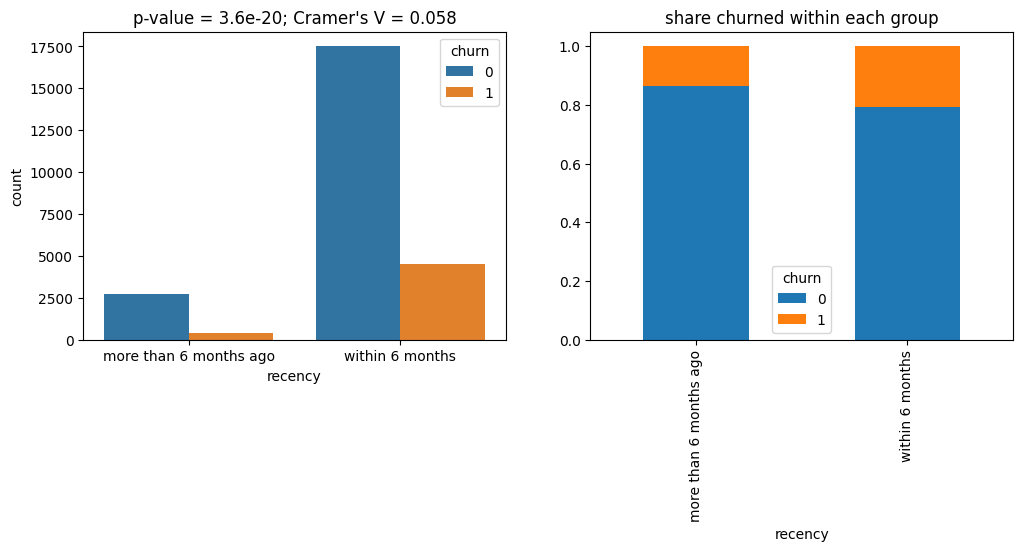

In [64]:
BVA_categorical_plot(transaction, 'churn', 'recency')

**Result:**

The opposite of the hypothesis: customers inactive for more than 6 months churn *less* (13.6%) than those who transacted within 6 months (20.6%). This is the strongest of the categorical effects tested here, though still weak (Cramér's V 0.06). Customers with no recorded last transaction churn even less (9.3%). A likely reading is that long-dormant accounts are simply left open rather than closed, while churners are active customers who move their money out.

### 7. Possibility that cities and branch code with very few accounts may lead to churning.

#### City

In [65]:
# getting city codes which have less than 280 (1%) of accounts
tmp = data['city'].value_counts()[:]
cities = tmp[tmp<280].index

In [66]:
churn_acc = data[['churn','city']].dropna().copy()
churn_acc['city_cat'] = np.where(churn_acc['city'].isin(cities), 'low accounts', 'high accounts')

               churn rate  customers
city_cat                            
high accounts       0.178      15020
low accounts        0.193      12559

p-value = 0.00082; significant = True; Cramer's V = 0.020


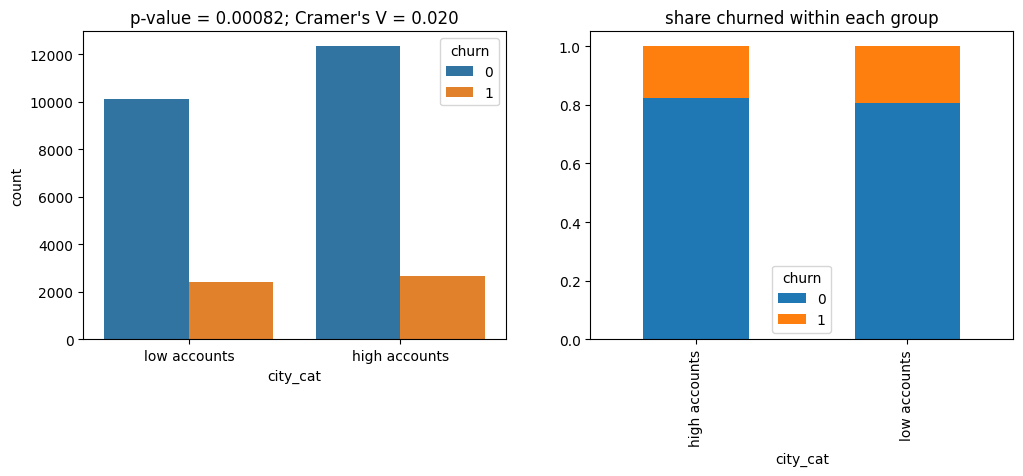

In [67]:
BVA_categorical_plot(churn_acc, 'churn', 'city_cat')

**Result:**

Cities with fewer than 280 accounts (1% of the total) churn slightly more: 19.3% against 17.8%. Significant (p < 0.001) but small (Cramér's V 0.02).

#### branch_code

Branches with fewer than 140 accounts (0.5% of the total) are compared with the rest. Almost every branch is below that threshold, so the 'high accounts' group is only 287 customers.

In [68]:
# getting branch codes with more than 0.5% of total accounts
tmp = data['branch_code'].value_counts()[:]
branch = tmp[tmp<140].index

In [69]:
# making two segments
churn_acc = data[['churn','branch_code']].copy()
churn_acc['branch_cat'] = np.where(churn_acc['branch_code'].isin(branch), 'low accounts', 'high accounts')

               churn rate  customers
branch_cat                          
high accounts       0.199        287
low accounts        0.185      28095

p-value = 0.61; significant = False; Cramer's V = 0.003


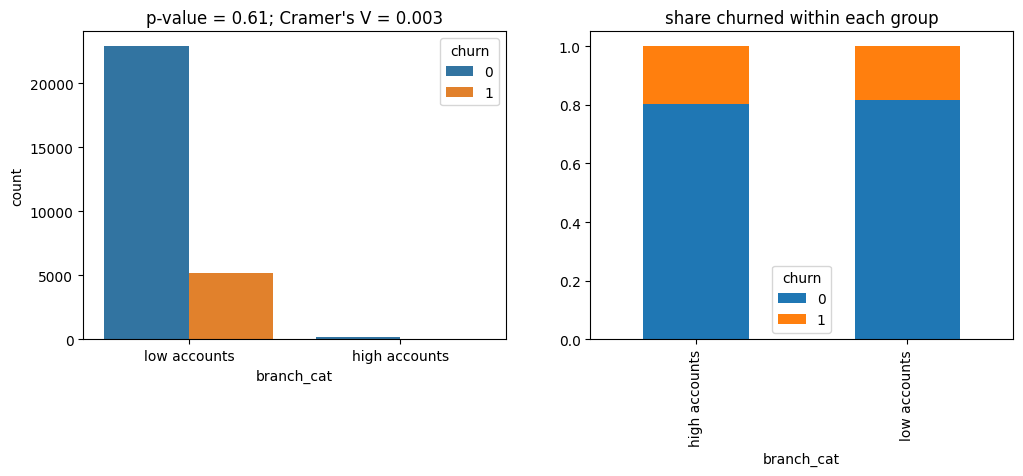

In [70]:
BVA_categorical_plot(churn_acc, 'churn', 'branch_cat')

**Result:**

No significant difference: 19.9% for the few large branches against 18.5% for the rest (p = 0.61).

### Missing Values: Gender

In [71]:
# flagging rows with missing gender
miss_gender = data.copy()
miss_gender['missing_gender'] = np.where(miss_gender['gender'].isna(), 'missing value', 'not_missing')

                churn rate  customers
missing_gender                       
missing value        0.202        525
not_missing          0.185      27857

p-value = 0.35; significant = False; Cramer's V = 0.006


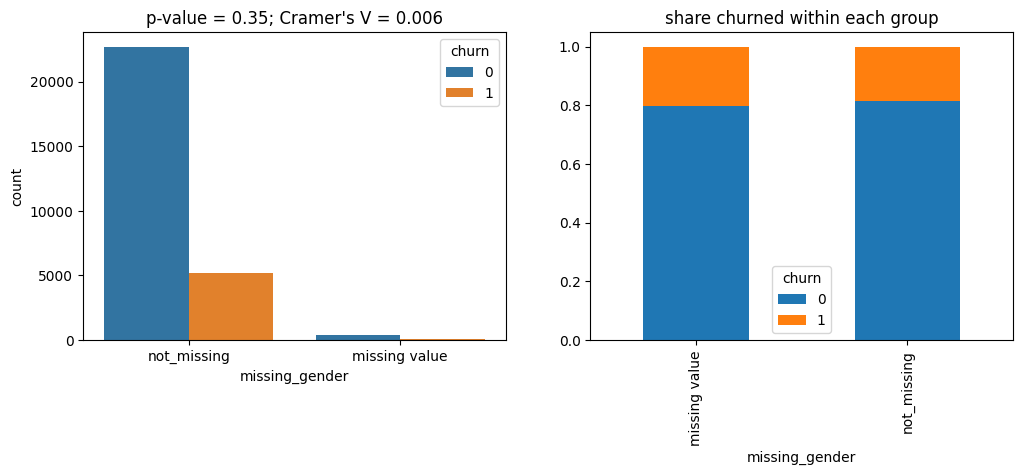

In [72]:
BVA_categorical_plot(miss_gender, 'churn', 'missing_gender')

**Result:**

Customers with missing gender churn at 20.2% against 18.5%, which is not significantly different (p = 0.35).

### Missing values : Depedents

In [73]:
# flagging rows with missing dependents
miss_dependents = data.copy()
miss_dependents['missing_dependents'] = np.where(miss_dependents['dependents'].isna(), 'missing value', 'not_missing')

                    churn rate  customers
missing_dependents                       
missing value            0.214       2463
not_missing              0.183      25919

p-value = 0.00014; significant = True; Cramer's V = 0.023


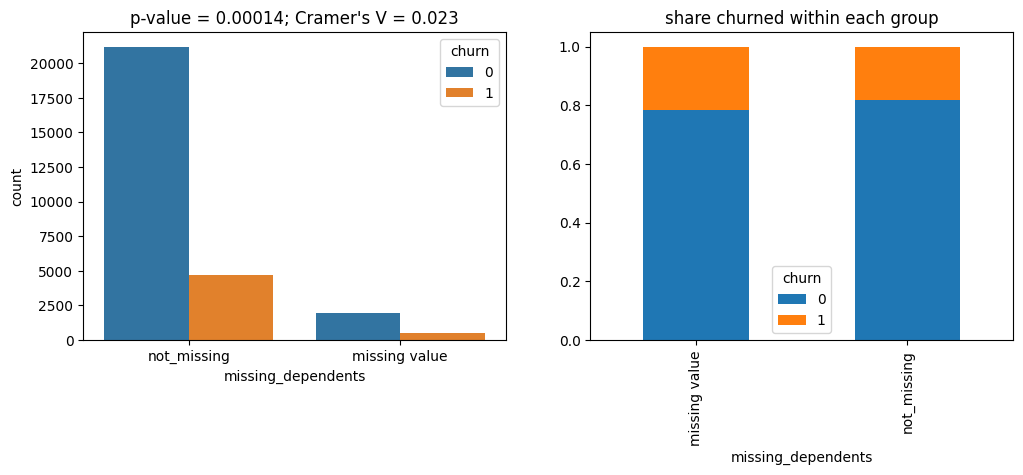

In [74]:
BVA_categorical_plot(miss_dependents, 'churn', 'missing_dependents')

**Result:**

Customers with missing dependents churn more: 21.4% against 18.3% (p < 0.001, Cramér's V 0.02). The missing value may carry information, so it should be kept as its own category rather than filled with 0.

### Missing values : Occupation

In [75]:
# flagging rows with missing occupation
miss_occupation = data.copy()
miss_occupation['missing_occupation'] = np.where(miss_occupation['occupation'].isna(), 'missing value', 'not_missing')

                    churn rate  customers
missing_occupation                       
missing value            0.162         80
not_missing              0.185      28302

p-value = 0.7; significant = False; Cramer's V = 0.002


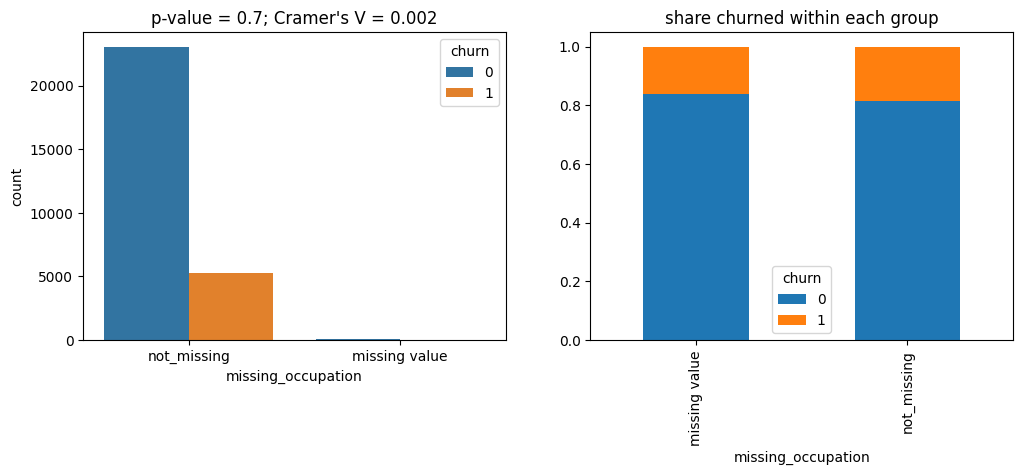

In [76]:
BVA_categorical_plot(miss_occupation, 'churn', 'missing_occupation')

**Result:**

Missing occupation (80 customers) is not related to churn (p = 0.70).

## Conclusion

- **18.5% of customers churned.**
- **No single customer attribute explains much of it.** Every categorical association tested has a Cramér's V of 0.06 or less. With 28,382 customers, even differences of one or two percentage points pass a significance test, so the churn rates themselves are the better guide.
- **Recency matters, but not the way it was expected to.** Customers inactive for more than 6 months churn *less* (13.6%) than recently active ones (20.6%).
- **Groups that churn somewhat more:** adults aged 18–59 (19.4%), customers with 1–3 dependents (22.5%), men (19.2%), self-employed customers (19.8%) and customers whose dependents value is missing (21.4%).
- **Hypotheses not supported:**
  - Young customers churn *less*.
  - Net worth category barely matters.
  - Branch size makes no difference.
- **Balances and transactions are heavily skewed,** with many outliers that keep the same pattern from month to month. Balance variables are strongly correlated with each other and credit/debit variables moderately so, while the two groups are nearly unrelated. The balance variables in particular could be combined into fewer features.
- **Next step:** the weak one-variable effects suggest churn depends on combinations of behaviour, such as balance changes between months. A multivariate model would be the natural next step.
